In [10]:
import pyodbc
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

In [88]:
conn = pyodbc.connect(
    "Driver={SQL Server};"
    "Server=DESKTOP-VLFE06R;"
    "Database=vendor;"
    "Trusted_Connection=yes;"
)

In [89]:
server = "DESKTOP-VLFE06R"
database = "vendor"

In [90]:
engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver=SQL+Server&trusted_connection=yes"
)

# Exploratory Data Analysis

Understanding the dataset to explore how the data is present in the database and if there id a need of creating some aggregated tables that an help with:

1.) Vendor selection for profitability
2.) Product Pricing Optimization

In [17]:
tables = "SELECT name FROM sys.tables"
tables = pd.read_sql(tables, engine)
print(tables)

              name
0  begin_inventory
1    end_inventory
2  purchase_prices
3        purchases
4   vendor_invoice
5            sales


In [22]:
for table in tables['name']:
    print('-' * 50, f'{table}', '-' * 50)
    
    count_df = pd.read_sql(f"SELECT COUNT(*) AS count FROM {table}", engine)
    print('Count of records:', count_df['count'].values[0])
    
    display(pd.read_sql(f"SELECT Top 5 * FROM {table}", engine))
          

-------------------------------------------------- begin_inventory --------------------------------------------------
Count of records: 206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.990000,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.990000,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.990002,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.990002,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.990002,2024-01-01


-------------------------------------------------- end_inventory --------------------------------------------------
Count of records: 224489


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.990000,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.990002,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.990002,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.990002,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.990000,2024-12-31


-------------------------------------------------- purchase_prices --------------------------------------------------
Count of records: 12261


...

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


-------------------------------------------------- vendor_invoice --------------------------------------------------
Count of records: 5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


-------------------------------------------------- sales --------------------------------------------------
Count of records: 7999999


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-01,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,2.0,32.98,16.49,2024-01-02,750.0,1.0,1.57,12546.0,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-03,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,1.0,14.49,14.49,2024-01-08,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1.0,1005.0,Maker's Mark Combo Pack,375mL 2 Pk,2.0,69.98,34.99,2024-01-09,375.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY


In [23]:
purchases = pd.read_sql_query("select * from purchases where VendorNumber = 4466",engine)
purchases

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,38_GOULCREST_5215,38,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-07,2024-01-19,2024-02-26,9.41,6,56.46,1
1,59_CLAETHORPES_5215,59,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
2,67_EANVERNESS_5215,67,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-08,2024-01-19,2024-02-26,9.41,6,56.46,1
3,48_NORFOLK_5255,48,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.35,6,56.10,1
4,74_PAENTMARWY_5215,74,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,53_HILLFAR_5255,53,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-17,2024-08-24,2024-10-02,9.35,6,56.10,1
2188,14_BROMWICH_5255,14,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-15,2024-08-24,2024-10-02,9.35,12,112.20,1
2189,38_GOULCREST_3140,38,3140,TGI Fridays Orange Dream,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-16,2024-08-24,2024-10-02,11.19,6,67.14,1
2190,57_LANTEGLOS_5255,57,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-15,2024-08-24,2024-10-02,9.35,6,56.10,1


In [26]:
purchase_prices = pd.read_sql_query("select * from purchase_prices where VendorNumber = 4466",engine)
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750.0,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750.0,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750.0,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [27]:
vendor_invoice = pd.read_sql_query("select * from vendor_invoice where VendorNumber = 4466",engine)
vendor_invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-19,8207,2023-12-27,2024-02-26,335,3142.33,16.97,None
2,4466,AMERICAN VINTAGE BEVERAGE,2024-01-18,8307,2024-01-03,2024-02-18,41,383.35,1.99,None
3,4466,AMERICAN VINTAGE BEVERAGE,2024-01-27,8469,2024-01-14,2024-03-11,72,673.20,3.30,None
4,4466,AMERICAN VINTAGE BEVERAGE,2024-02-04,8532,2024-01-19,2024-03-15,79,740.21,3.48,None
5,4466,AMERICAN VINTAGE BEVERAGE,2024-02-09,8604,2024-01-24,2024-03-15,347,3261.37,17.61,None
6,4466,AMERICAN VINTAGE BEVERAGE,2024-02-17,8793,2024-02-05,2024-04-02,72,675.36,3.17,None
7,4466,AMERICAN VINTAGE BEVERAGE,2024-03-01,8892,2024-02-12,2024-03-28,117,1096.05,5.15,None
8,4466,AMERICAN VINTAGE BEVERAGE,2024-03-07,8995,2024-02-19,2024-04-02,129,1209.27,5.44,None
9,4466,AMERICAN VINTAGE BEVERAGE,2024-03-12,9033,2024-02-22,2024-04-16,147,1377.87,6.61,None


In [29]:
sales = pd.read_sql_query("select * from sales where VendorNo = 4466",engine)
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,1.0,12.99,12.99,2024-01-08,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
1,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,1.0,12.99,12.99,2024-01-13,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
2,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,1.0,12.99,12.99,2024-01-22,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
3,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,2.0,25.98,12.99,2024-01-28,1750.0,1.0,3.67,4466.0,AMERICAN VINTAGE BEVERAGE
4,15_WANBORNE_5255,15.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-01-06,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5718,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-21,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
5719,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-25,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
5720,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-26,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
5721,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-27,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE


In [31]:
purchases.groupby(['Brand', 'PurchasePrice'])[['Quantity','Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
3140,11.19,4640,51921.60
5215,9.41,4923,46325.43
5255,9.35,6215,58110.25


In [32]:
vendor_invoice['PONumber'].nunique()

55

In [33]:
vendor_invoice.shape

(55, 10)

purchases -> vendor_invoice + purchase_prices

In [34]:
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,1.0,12.99,12.99,2024-01-08,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
1,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,1.0,12.99,12.99,2024-01-13,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
2,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,1.0,12.99,12.99,2024-01-22,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
3,15_WANBORNE_5215,15.0,5215.0,TGI Fridays Long Island Iced,1.75L,2.0,25.98,12.99,2024-01-28,1750.0,1.0,3.67,4466.0,AMERICAN VINTAGE BEVERAGE
4,15_WANBORNE_5255,15.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-01-06,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5718,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-21,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
5719,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-25,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
5720,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-26,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE
5721,71_CLARCTON_5255,71.0,5255.0,TGI Fridays Ultimte Mudslide,1.75L,1.0,12.99,12.99,2024-08-27,1750.0,1.0,1.84,4466.0,AMERICAN VINTAGE BEVERAGE


In [35]:
purchases

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,38_GOULCREST_5215,38,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-07,2024-01-19,2024-02-26,9.41,6,56.46,1
1,59_CLAETHORPES_5215,59,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
2,67_EANVERNESS_5215,67,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-08,2024-01-19,2024-02-26,9.41,6,56.46,1
3,48_NORFOLK_5255,48,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.35,6,56.10,1
4,74_PAENTMARWY_5215,74,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,53_HILLFAR_5255,53,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-17,2024-08-24,2024-10-02,9.35,6,56.10,1
2188,14_BROMWICH_5255,14,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-15,2024-08-24,2024-10-02,9.35,12,112.20,1
2189,38_GOULCREST_3140,38,3140,TGI Fridays Orange Dream,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-16,2024-08-24,2024-10-02,11.19,6,67.14,1
2190,57_LANTEGLOS_5255,57,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,11540,2024-08-08,2024-08-15,2024-08-24,2024-10-02,9.35,6,56.10,1


In [36]:
sales.groupby('Brand')[['SalesDollars', 'SalesPrice', 'SalesQuantity']].sum()

,SalesDollars,SalesPrice,SalesQuantity
Brand,,,
3140.0,32059.32,17016.90,2468.0
5215.0,39788.37,26239.80,3063.0
5255.0,48777.45,31085.07,3755.0


1.) The purchases table contains actual purchase data, including the data of purchase, products(brands) purchased by vendors, the amount paid (in dollars), and the quantity purchased.

2.) The purchase price column is derived from the purchase_prices table, which provides product-wise actual and purchase prices. The combination of vendor and brand is unique in this table.

3.) The vendor_invoice table aggregates data from the purchases table, summarizing quantity and dollar amounts, along with an additional column for freight.

This Table maintains uniqueness based on vendor and PO number.

4.) The sales table captures actual sales transactions, detailing the brands purchased by vendors, the quantity sold, the selling price, and the revenue earned.

As the data that we need for analysis is distributed in different tables, we need to create a summary table containing:
* purchase transactions made by vendors
* sales transaction data
* freight costs for each vendor
* actual product prices from vendors

In [37]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='str')

In [39]:
freight_summary = pd.read_sql_query('''select VendorNumber, sum(Freight) as FreightCost
                                    From vendor_invoice
                                    Group By VendorNumber''', engine)

In [40]:
freight_summary

,VendorNumber,FreightCost
0,6830,360.29
1,8920,232.99
2,17032,283.61
3,7749,91.50
4,4692,9139.38
...,...,...
121,11567,20964.81
122,2450,251.28
123,7239,16978.67
124,8664,18544.49


In [44]:
pd.read_sql_query("""
SELECT
    p.VendorNumber,
    p.VendorName,
    p.Brand,
    p.PurchasePrice,
    pp.Volume,
    pp.Price AS ActualPrice,
    SUM(p.Quantity) AS TotalPurchaseQuantity,
    SUM(p.Dollars) AS TotalPurchaseDollars
FROM purchases p
JOIN purchase_prices pp
    ON p.Brand = pp.Brand
    WHERE p.purchasePrice > 0
GROUP BY 
    p.VendorNumber, 
    p.VendorName, 
    p.Brand,
    p.PurchasePrice,
    pp.Volume,
    pp.Price
ORDER BY TotalPurchaseDollars
""", engine)

,VendorNumber,VendorName,Brand,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,50.0,0.99,1,0.71
1,3960,DIAGEO NORTH AMERICA INC,6127,1.47,200.0,1.99,1,1.47
2,3924,HEAVEN HILL DISTILLERIES,9123,0.74,50.0,0.99,2,1.48
3,8004,SAZERAC CO INC,5683,0.39,50.0,0.49,6,2.34
4,9815,WINE GROUP INC,8527,1.32,750.0,4.99,2,2.64
...,...,...,...,...,...,...,...,...
10687,3960,DIAGEO NORTH AMERICA INC,3545,21.89,1750.0,29.99,138109,3023206.01
10688,3960,DIAGEO NORTH AMERICA INC,4261,16.17,1750.0,22.99,201682,3261197.94
10689,17035,PERNOD RICARD USA,8068,18.24,1750.0,24.99,187407,3418303.68
10690,4425,MARTIGNETTI COMPANIES,3405,23.19,1750.0,28.99,164038,3804041.22


In [45]:
sales.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='str')

In [46]:
pd.read_sql_query("""SELECT
VendorNo,
Brand,
SUM(SalesDollars) as TotalSalesDollars,
SUM(SalesPrice) as TotalSalesPrice,
SUM(SalesQuantity) as TotalSalesQuantity,
SUM(ExciseTax) as TotalExciseTax
From sales
Group By VendorNo, Brand
Order By TotalSalesDollars""", engine)

,VendorNo,Brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax
0,8004.0,5287.0,0.98,0.98,2.0,0.10
1,9206.0,2773.0,0.99,0.99,1.0,0.05
2,3252.0,3933.0,1.98,0.99,2.0,0.10
3,10050.0,3623.0,1.98,1.98,2.0,0.10
4,660.0,2134.0,2.49,2.49,1.0,0.39
...,...,...,...,...,...,...
10163,3960.0,4261.0,2433441.40,272709.66,106960.0,196530.22
10164,3960.0,3545.0,2636638.48,354201.88,84952.0,156089.95
10165,4425.0,3405.0,2917588.98,367317.66,96698.0,177673.04
10166,17035.0,8068.0,2984371.19,305197.12,122981.0,225967.30


### JOINING 3 ABOVE TABLE USING JOINS

In [52]:
import time
start = time.time()

final_table = pd.read_sql_query("""
SELECT
    pp.VendorNumber,
    pp.Brand,
    CAST(pp.Price AS DECIMAL(10,2)) AS ActualPrice,
    CAST(pp.PurchasePrice AS DECIMAL(10,2)) AS PurchasePrice,

    SUM(CAST(s.SalesQuantity AS DECIMAL(10,2))) AS TotalSalesQuantity,
    SUM(CAST(s.SalesDollars AS DECIMAL(10,2))) AS TotalSalesDollars,
    SUM(CAST(s.SalesPrice AS DECIMAL(10,2))) AS TotalSalesPrice,
    SUM(CAST(s.ExciseTax AS DECIMAL(10,2))) AS TotalExciseTax,

    SUM(CAST(vi.Quantity AS DECIMAL(10,2))) AS TotalPurchaseQuantity,
    SUM(CAST(vi.Dollars AS DECIMAL(10,2))) AS TotalPurchaseDollars,
    SUM(CAST(vi.Freight AS DECIMAL(10,2))) AS TotalFreightCost

FROM purchase_prices pp
JOIN sales s
    ON pp.VendorNumber = s.VendorNo
    AND pp.Brand = s.Brand
JOIN vendor_invoice vi
    ON pp.VendorNumber = vi.VendorNumber
GROUP BY 
    pp.VendorNumber, 
    pp.Brand, 
    pp.Price, 
    pp.PurchasePrice
""", engine)

end = time.time()

In [54]:
final_table

,VendorNumber,Brand,ActualPrice,PurchasePrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost
0,4425,26853,29.99,20.68,656.0,19673.44,14755.08,72.16,1.584247e+07,1.671701e+08,8.695754e+05
1,653,17200,12.99,8.78,17545.0,169224.55,76699.70,1955.25,2.249743e+07,2.233336e+08,1.170187e+06
2,480,8154,21.99,16.05,112475.0,2495930.25,1732214.55,88651.75,2.025019e+09,2.500899e+10,1.266972e+08
3,90024,14703,11.99,7.58,22990.0,277575.10,173822.00,2547.60,1.545128e+07,1.427024e+08,7.286864e+05
4,7153,21960,5.99,4.02,8250.0,54345.50,11487.85,233.20,1.400609e+07,1.032594e+08,5.241991e+05
...,...,...,...,...,...,...,...,...,...,...,...
10113,4425,16072,6.99,4.60,328.0,2292.72,573.18,147.60,2.640411e+06,2.786169e+07,1.449292e+05
10114,9165,23389,13.99,7.53,56650.0,663008.50,472651.30,6271.65,7.909048e+08,9.696591e+09,4.995215e+07
10115,8112,4164,599.99,454.54,110.0,65998.90,65998.90,115.50,8.557340e+05,1.894599e+07,9.669452e+04
10116,9165,3654,53.99,39.39,101970.0,5470435.30,4004299.20,80410.55,1.461127e+09,1.791359e+10,9.228217e+07


### OPTIMISED SQL SCRIPT OF ABOVE SCRIPT

In [55]:
vendor_sales_summary = pd.read_sql_query("""WITH FreightSummary as (
    SELECT
        VendorNumber,
        SUM(Freight) as FreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber
),

PurchaseSummary as (
    SELECT
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price as ActualPrice,
        pp.Volume,
        SUM(p.Quantity) as TotalPurchaseQuantity,
        SUM(p.Dollars) as TotalPurchaseDollars
    FROM purchases p
    JOIN purchase_prices pp
        ON p.Brand = pp.Brand
    WHERE p.PurchasePrice > 0
    GROUP BY p.VendorNumber, p.VendorName, p.Brand, p.Description, p.PurchasePrice, pp.Price, pp.Volume
),

SalesSummary as (
    SELECT
        VendorNo,
        Brand,
        SUM(SalesQuantity) as TotalSalesQuantity,
        SUM(SalesDollars) as TotalSalesDollars,
        SUM(SalesPrice) as TotalSalesPrice,
        SUM(ExciseTax) as TotalExciseTax
     FROM sales
     GROUP BY VendorNo, Brand
)

SELECT
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.PurchasePrice,
    ps.ActualPrice,
    ps.Volume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesQuantity,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalExciseTax,
    fs.FreightCost
FROM PurchaseSummary ps
LEFT JOIN SalesSummary ss
    ON ps.VendorNumber = ss.VendorNo
    AND ps.Brand = ss.Brand
LEFT JOIN FreightSummary fs
    ON ps.VendorNumber = fs.VendorNumber
ORDER BY ps.TotalPurchaseDollars DESC """, engine)


In [57]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,88517.0,3164719.83,439838.72,162639.63,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,96698.0,2917588.98,367317.66,177673.04,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,122981.0,2984371.19,305197.12,225967.30,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,106960.0,2433441.40,272709.66,196530.22,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,84952.0,2636638.48,354201.88,156089.95,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,62.72,0.98,6.72,50293.62
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,NaN,NaN,NaN,NaN,14069.87
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,42.0,83.58,41.79,8.82,257032.07


This query generates a vendor-wise sales and purchase summary, which is valuable for :

#### Performance Optimization

* The query involves heavy joins and aggregations on large datasets like sales and purchases.
* Storing the pre-aggregated results avoids repeated expensive computations.
* Helps in analyzing sales, purchases, and pricing for different vendors and brands
* Future Benefits of Storing this data for faster Dashboarding & Reporting
* Instead of running expensive queries each time, dashboards can fetch data quickly from vendor_sales_summary.

# Data Cleaning

In [58]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                   str
Brand                      int64
Description                  str
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
dtype: object

In [59]:
vendor_sales_summary.isnull().sum()

VendorNumber                0
VendorName                  0
Brand                       0
Description                 0
PurchasePrice               0
ActualPrice                 0
Volume                      0
TotalPurchaseQuantity       0
TotalPurchaseDollars        0
TotalSalesQuantity       1264
TotalSalesDollars        1264
TotalSalesPrice          1264
TotalExciseTax           1264
FreightCost                 0
dtype: int64

vendor buy the product but can't able to sell. that why 1264 null records

In [60]:
vendor_sales_summary['VendorName'].unique()

<StringArray>
['BROWN-FORMAN CORP          ',       'MARTIGNETTI COMPANIES',
 'PERNOD RICARD USA          ', 'DIAGEO NORTH AMERICA INC   ',
 'BACARDI USA INC            ', 'JIM BEAM BRANDS COMPANY    ',
 'MAJESTIC FINE WINES        ', 'ULTRA BEVERAGE COMPANY LLP ',
 'STOLI GROUP,(USA) LLC      ', 'PROXIMO SPIRITS INC.       ',
 ...
             'UNCORKED       ', 'BRONCO WINE COMPANY        ',
 'MILTONS DISTRIBUTING CO    ', 'TRUETT HURST               ',
 'LAUREATE IMPORTS CO        ', 'FANTASY FINE WINES CORP    ',
 'AAPER ALCOHOL & CHEMICAL CO', 'SILVER MOUNTAIN CIDERS     ',
 'CAPSTONE INTERNATIONAL     ', 'FLAVOR ESSENCE INC         ']
Length: 129, dtype: str

In [61]:
vendor_sales_summary['Description'].unique()

<StringArray>
[    'Jack Daniels No 7 Black',       'Tito's Handmade Vodka',
            'Absolut 80 Proof',      'Capt Morgan Spiced Rum',
             'Ketel One Vodka',            'Grey Goose Vodka',
       'Jameson Irish Whiskey',           'Smirnoff Traveler',
                   'Tanqueray',                    'Jim Beam',
 ...
         'Riunite Sweet White',         'Firefly Ridge Chard',
           'Debauchery Pnt Nr', 'Terruzzi & Puthod Vernaccia',
  'Santa Rita Organic Svgn Bl',    'Aresti Pnt Nr Curico Vly',
   'Smirnoff Light Strawberry',           'Crown Royal Apple',
 'Concannon Glen Ellen Wh Zin', 'The Club Strawbry Margarita']
Length: 9651, dtype: str

Data Cleaning
* Changing data type of TotalPurchaseQuantity from int to float
* Handling missing value in TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax
* In string/object type of column we have to remove white/extra space

In [62]:
vendor_sales_summary['TotalPurchaseQuantity'] = vendor_sales_summary['TotalPurchaseQuantity'].astype('float64')

In [139]:
vendor_sales_summary.fillna(0, inplace = True)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,88517,3164719.83,439838.72,162639.63,68601.68,-646531.77,-20.429353,0.610125,0.830362
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,96698,2917588.98,367317.66,177673.04,144929.24,-886452.24,-30.383040,0.589485,0.766971
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,122981,2984371.19,305197.12,225967.30,123780.22,-433932.49,-14.540165,0.656224,0.873056
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,106960,2433441.40,272709.66,196530.22,257032.07,-827756.54,-34.015881,0.530340,0.746180
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,84952,2636638.48,354201.88,156089.95,257032.07,-386567.53,-14.661378,0.615108,0.872133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,128,62.72,0.98,6.72,50293.62,60.38,96.269133,21.333333,26.803419
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,0,0.00,0.00,0.00,14069.87,-1.48,0.000000,0.000000,0.000000
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,42,83.58,41.79,8.82,257032.07,82.11,98.241206,42.000000,56.857143


In [66]:
vendor_sales_summary['VendorName'] = vendor_sales_summary['VendorName'].str.strip()

In [67]:
vendor_sales_summary['Description'] = vendor_sales_summary['Description'].str.strip()

After Cleaning

In [68]:
vendor_sales_summary.dtypes

VendorNumber               int64
VendorName                   str
Brand                      int64
Description                  str
PurchasePrice            float64
ActualPrice              float64
Volume                   float64
TotalPurchaseQuantity    float64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
dtype: object

In [69]:
vendor_sales_summary.isnull().sum()

VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
dtype: int64

In [70]:
vendor_sales_summary['VendorName'].unique()

<StringArray>
[          'BROWN-FORMAN CORP',       'MARTIGNETTI COMPANIES',
           'PERNOD RICARD USA',    'DIAGEO NORTH AMERICA INC',
             'BACARDI USA INC',     'JIM BEAM BRANDS COMPANY',
         'MAJESTIC FINE WINES',  'ULTRA BEVERAGE COMPANY LLP',
       'STOLI GROUP,(USA) LLC',        'PROXIMO SPIRITS INC.',
 ...
                    'UNCORKED',         'BRONCO WINE COMPANY',
     'MILTONS DISTRIBUTING CO',                'TRUETT HURST',
         'LAUREATE IMPORTS CO',     'FANTASY FINE WINES CORP',
 'AAPER ALCOHOL & CHEMICAL CO',      'SILVER MOUNTAIN CIDERS',
      'CAPSTONE INTERNATIONAL',          'FLAVOR ESSENCE INC']
Length: 128, dtype: str

In [71]:
vendor_sales_summary['Description'].unique()

<StringArray>
[    'Jack Daniels No 7 Black',       'Tito's Handmade Vodka',
            'Absolut 80 Proof',      'Capt Morgan Spiced Rum',
             'Ketel One Vodka',            'Grey Goose Vodka',
       'Jameson Irish Whiskey',           'Smirnoff Traveler',
                   'Tanqueray',                    'Jim Beam',
 ...
         'Riunite Sweet White',         'Firefly Ridge Chard',
           'Debauchery Pnt Nr', 'Terruzzi & Puthod Vernaccia',
  'Santa Rita Organic Svgn Bl',    'Aresti Pnt Nr Curico Vly',
   'Smirnoff Light Strawberry',           'Crown Royal Apple',
 'Concannon Glen Ellen Wh Zin', 'The Club Strawbry Margarita']
Length: 9651, dtype: str

## Creating New Additional/Helper/Analysis Column

### Creating New Column for Further Data Analysis
#### 1. Gross Profit
#### 2. ProfitMargin
#### 3. StockTurnover
#### 4. SalestoPurchaseRatio

In [125]:
vendor_sales_summary['GrossProfit'] = vendor_sales_summary['TotalSalesDollars'] - vendor_sales_summary['TotalPurchaseDollars']

In [126]:
vendor_sales_summary['ProfitMargin'] = (vendor_sales_summary['GrossProfit'] / vendor_sales_summary['TotalSalesDollars'])*100

In [127]:
vendor_sales_summary['StockTurnover'] = vendor_sales_summary['TotalSalesQuantity']/vendor_sales_summary['TotalPurchaseQuantity']

In [128]:
vendor_sales_summary['SalesToPurchaseRatio'] = vendor_sales_summary['TotalSalesDollars']/vendor_sales_summary['TotalPurchaseDollars']

### Adding 4 Column with previous all column to create a new table name vendor_sales_summary

In [129]:
from sqlalchemy import text

with engine.connect() as connection:
    connection.execute(text("""
        CREATE TABLE vendor_sales_summary (
            VendorNumber INT,
            VendorName VARCHAR(100),
            Brand INT,
            Description VARCHAR(100),
            PurchasePrice DECIMAL(10,2),
            ActualPrice DECIMAL(10,2),
            Volume INT,
            TotalPurchaseQuantity INT,
            TotalPurchaseDollars DECIMAL(15,2),
            TotalSalesQuantity INT,
            TotalSalesDollars DECIMAL(15,2),
            TotalSalesPrice DECIMAL(15,2),
            TotalExciseTax DECIMAL(15,2),
            FreightCost DECIMAL(15,2),
            GrossProfit DECIMAL(15,2),
            ProfitMargin DECIMAL(15,2),
            StockTurnover DECIMAL(15,2),
            SalesToPurchaseRatio DECIMAL(15,2),
            PRIMARY KEY (VendorNumber, Brand)
        );
    """))
    connection.commit()

In [130]:
pd.read_sql_query("select * from vendor_sales_summary", engine)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


Adding rows in table

In [99]:
from sqlalchemy import create_engine
import urllib

params = urllib.parse.quote_plus(
    "DRIVER=ODBC Driver 17 for SQL Server;"
    "SERVER=DESKTOP-VLFE06R;"
    "DATABASE=vendor;"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    fast_executemany=True,
    use_setinputsizes=False
)

In [100]:
from sqlalchemy import text

with engine.connect() as conn:
    print(conn.execute(text("SELECT @@VERSION")).scalar())

Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) 
	Oct  8 2022 05:58:25 
	Copyright (C) 2022 Microsoft Corporation
	Developer Edition (64-bit) on Windows 10 Home Single Language 10.0 <X64> (Build 22631: ) (Hypervisor)



In [131]:
vendor_sales_summary["VendorNumber"] = vendor_sales_summary["VendorNumber"].astype(int)
vendor_sales_summary["Brand"] = vendor_sales_summary["Brand"].astype(int)

vendor_sales_summary["Volume"] = vendor_sales_summary["Volume"].astype(int)
vendor_sales_summary["TotalPurchaseQuantity"] = vendor_sales_summary["TotalPurchaseQuantity"].astype(int)
vendor_sales_summary["TotalSalesQuantity"] = vendor_sales_summary["TotalSalesQuantity"].astype(int)

vendor_sales_summary["TotalPurchaseDollars"] = vendor_sales_summary["TotalPurchaseDollars"].astype(float)
vendor_sales_summary["TotalSalesDollars"] = vendor_sales_summary["TotalSalesDollars"].astype(float)
vendor_sales_summary["TotalSalesPrice"] = vendor_sales_summary["TotalSalesPrice"].astype(float)
vendor_sales_summary["TotalExciseTax"] = vendor_sales_summary["TotalExciseTax"].astype(float)
vendor_sales_summary["FreightCost"] = vendor_sales_summary["FreightCost"].astype(float)
vendor_sales_summary["GrossProfit"] = vendor_sales_summary["GrossProfit"].astype(float)
vendor_sales_summary["ProfitMargin"] = vendor_sales_summary["ProfitMargin"].astype(float)
vendor_sales_summary["StockTurnover"] = vendor_sales_summary["StockTurnover"].astype(float)
vendor_sales_summary["SalesToPurchaseRatio"] = vendor_sales_summary["SalesToPurchaseRatio"].astype(float)

In [142]:
vendor_sales_summary.to_sql(
    'vendor_sales_summary',
    engine,
    schema='dbo',
    if_exists='append',
    index=False
)

-1

In [136]:
print(vendor_sales_summary.columns.tolist())

['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']


In [135]:
# Remove the wrong column completely
if 'SalestoPurchaseRatio' in vendor_sales_summary.columns:
    vendor_sales_summary = vendor_sales_summary.drop(columns=['SalestoPurchaseRatio'])

# Remove duplicate column names if any
vendor_sales_summary = vendor_sales_summary.loc[:, ~vendor_sales_summary.columns.duplicated()]

print(vendor_sales_summary.columns.tolist())

['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']


In [140]:
import numpy as np

vendor_sales_summary.replace([np.inf, -np.inf], np.nan, inplace=True)

print(vendor_sales_summary.isnull().sum())

VendorNumber             0
VendorName               0
Brand                    0
Description              0
PurchasePrice            0
ActualPrice              0
Volume                   0
TotalPurchaseQuantity    0
TotalPurchaseDollars     0
TotalSalesQuantity       0
TotalSalesDollars        0
TotalSalesPrice          0
TotalExciseTax           0
FreightCost              0
GrossProfit              0
ProfitMargin             0
StockTurnover            0
SalesToPurchaseRatio     0
dtype: int64


In [ ]:
vendor_sales_summary.fillna(0, inplace = True)

In [141]:
vendor_sales_summary = vendor_sales_summary.replace([np.inf, -np.inf], 0)
vendor_sales_summary = vendor_sales_summary.fillna(0)

In [143]:
pd.read_sql("SELECT COUNT(*) FROM dbo.vendor_sales_summary", engine)

,
0,10692


In [149]:
pd.read_sql_query("select * from vendor_sales_summary", engine)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,8,190.88,16,591.84,258.93,1.78,27.08,400.96,67.75,2.00,3.10
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162,320,5440.00,24,599.76,449.82,0.52,27.08,-4840.24,-807.03,0.08,0.11
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750,1,105.07,0,0.00,0.00,0.00,0.48,-105.07,0.00,0.00,0.00
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750,39,446.16,17,254.83,239.84,13.42,367.52,-191.33,-75.08,0.44,0.57
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750,6,66.60,0,0.00,0.00,0.00,367.52,-66.60,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,173357,TAMWORTH DISTILLING,2804,Camp Robber Whiskey,32.14,44.99,750,210,6749.40,0,0.00,0.00,0.00,202.50,-6749.40,0.00,0.00,0.00
10688,173357,TAMWORTH DISTILLING,3666,Art in the Age Chicory Root,18.79,24.99,375,520,9770.80,204,5097.96,2474.01,80.03,202.50,-4672.84,-91.66,0.39,0.52
10689,173357,TAMWORTH DISTILLING,3848,Chicory Root Vodka,23.30,30.99,750,28,652.40,0,0.00,0.00,0.00,202.50,-652.40,0.00,0.00,0.00
10690,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750,1232,23863.84,619,15468.81,8546.58,487.82,202.50,-8395.03,-54.27,0.50,0.65


In [145]:
df = pd.read_sql_query("select * from vendor_sales_summary", engine)

In [146]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,8,190.88,16,591.84,258.93,1.78,27.08,400.96,67.75,2.00,3.10
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162,320,5440.00,24,599.76,449.82,0.52,27.08,-4840.24,-807.03,0.08,0.11
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750,1,105.07,0,0.00,0.00,0.00,0.48,-105.07,0.00,0.00,0.00
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750,39,446.16,17,254.83,239.84,13.42,367.52,-191.33,-75.08,0.44,0.57
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750,6,66.60,0,0.00,0.00,0.00,367.52,-66.60,0.00,0.00,0.00


# Exploratory Data Analysis
* Previously we examined the various tables in the tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anaomalies, and ensure data quality before prodeeding with further analysis.

In [148]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
Volume,10692.0,847.360456,664.309309,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
TotalSalesQuantity,10692.0,1880.564160,6865.042855,0.00,13.0000,130.000,1107.0000,214058.00
TotalSalesDollars,10692.0,25675.669310,103453.146936,0.00,267.6075,2777.380,16861.9875,3164719.83
TotalSalesPrice,10692.0,11647.098820,28809.583306,0.00,80.4300,1432.745,9502.3625,439838.72


In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

Numerical columns: ['VendorNumber', 'Brand', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']
Number of numerical columns: 16


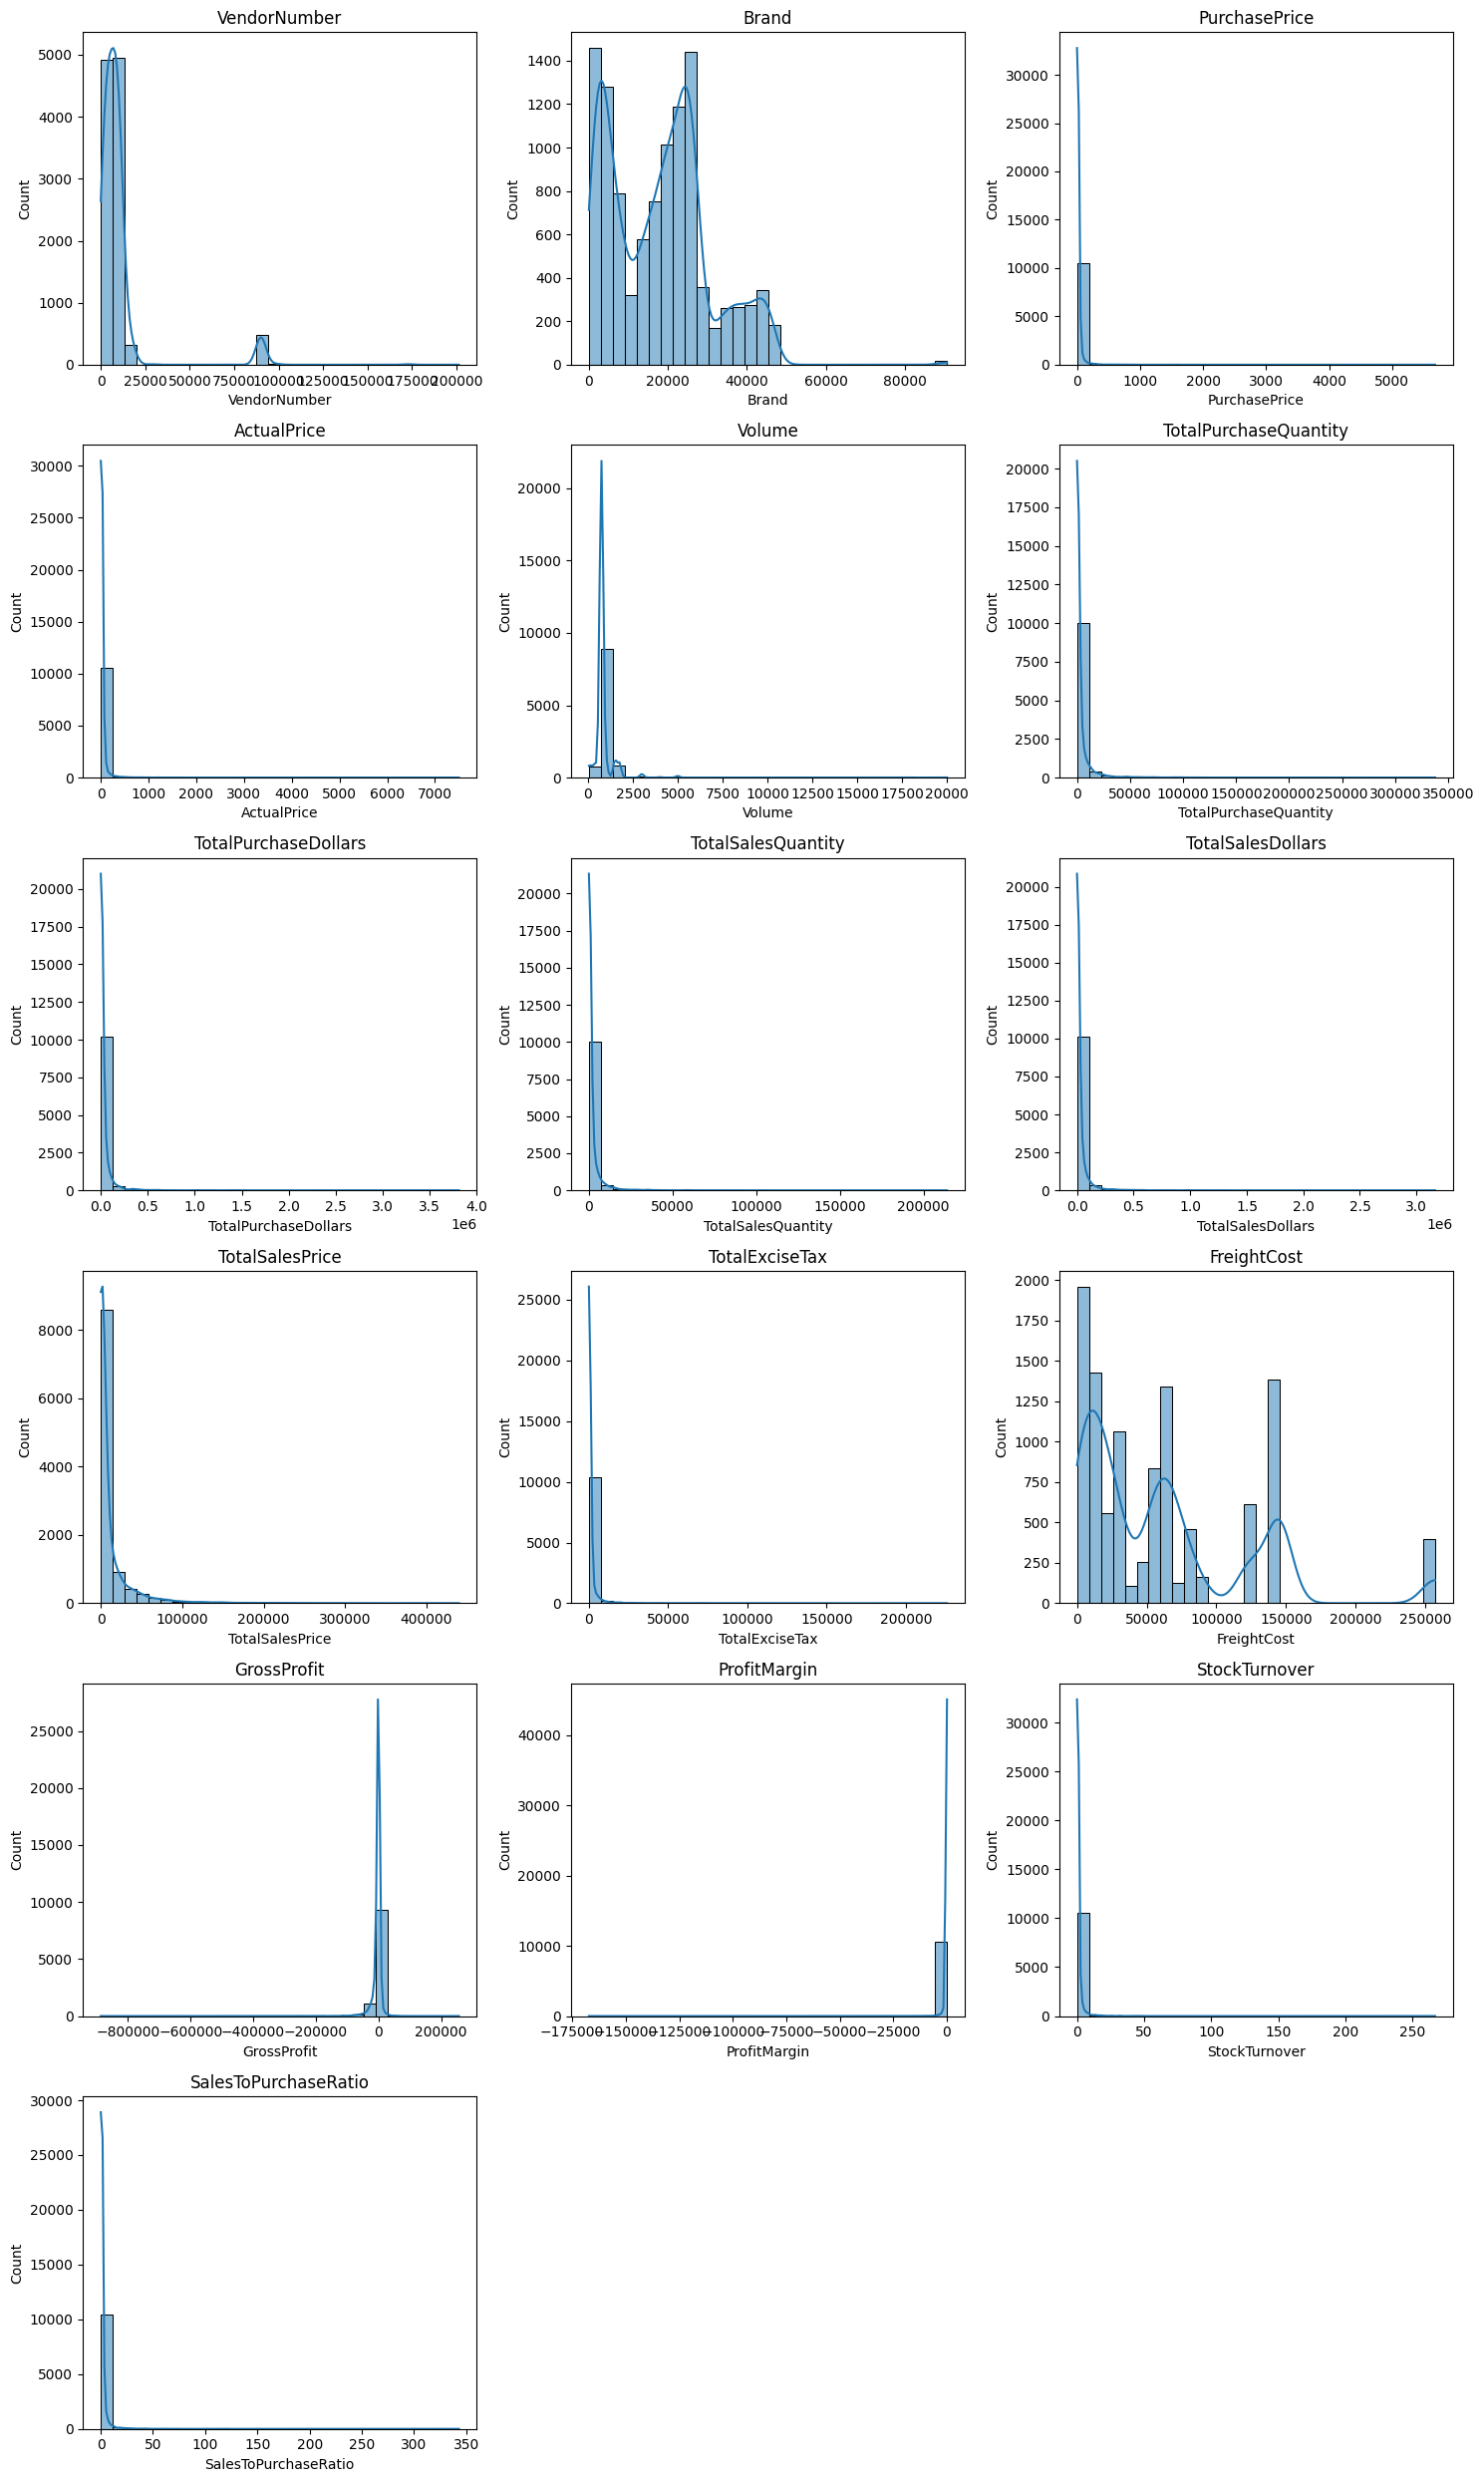

In [152]:
# Distribution Plots for Numerical Columns

numerical_cols = vendor_sales_summary.select_dtypes(include=np.number).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Number of numerical columns: {len(numerical_cols)}")

plt.figure(figsize=(15,25)) # Adjusted figure size for 6 rows
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 3, i+1) # Adjusted grid layout to 6 rows and 3 columns
    sns.histplot(vendor_sales_summary[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

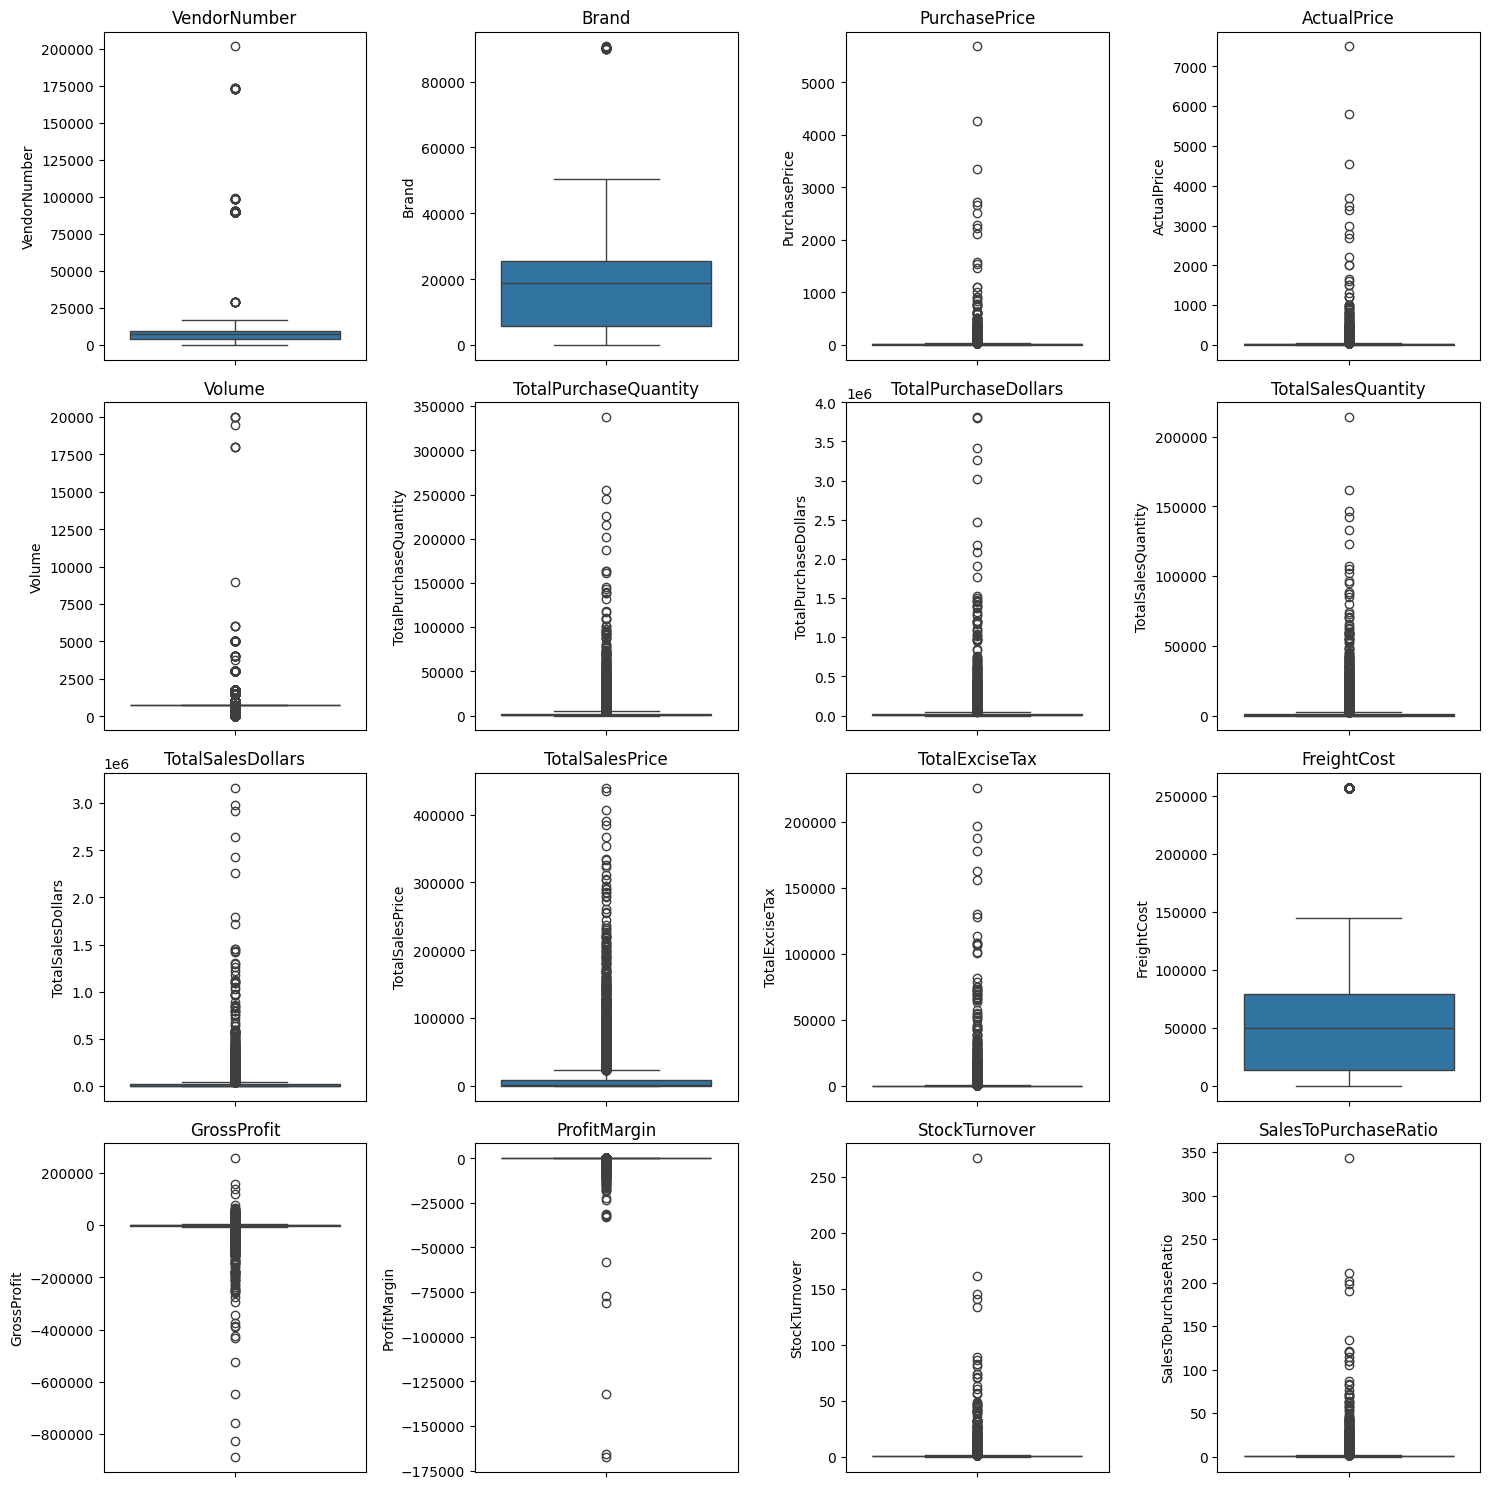

In [153]:
# Outlier Detection with Boxplots
numerical_cols = vendor_sales_summary.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,15)) # Adjusted figure size for 4 rows
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjusted grid layout to 4 rows and 4 columns for 16 plots
    sns.boxplot(y=vendor_sales_summary[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:

#### Negative & Zero Values:

* Gross Profit: Minimum value is -52,002.78, indicating losses.Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin : Has a minimum of -infinite, while suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars : Minimum values are 0 , meaning some products were purchased but never sold.These could be slow-moving or obsolete stock.
  
#### Outliers Indicated by High Standard Deviations:
* Purchase & Actual Price : The max values(5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64) , indicating potential premium products.
* Freight Cost : Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover : Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely.Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [184]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query(""" select * from vendor_sales_summary
Where GrossProfit > 0
And ProfitMargin > 0
And TotalSalesQuantity > 0""", engine)

In [185]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,8,190.88,16,591.84,258.93,1.78,27.08,400.96,67.75,2.00,3.10
1,388,ATLANTIC IMPORTING COMPANY,2119,Glendalough 13 Yr Sngle Malt,66.40,89.99,750,39,2589.60,87,7459.13,4799.44,68.61,211.74,4869.53,65.28,2.23,2.88
2,388,ATLANTIC IMPORTING COMPANY,7241,Glendalough Poitin Shry Cask,20.68,34.99,750,31,641.08,98,3039.02,2449.19,10.82,211.74,2397.94,78.91,3.16,4.74
3,480,BACARDI USA INC,129,Grey Goose L'Orange Vodka,24.99,31.99,1000,4,99.96,7,221.93,189.94,7.35,89286.27,121.97,54.96,1.75,2.22
4,480,BACARDI USA INC,540,Bacardi Pineapple Fusion,0.72,0.99,50,352,253.44,4452,4407.48,1898.82,229.43,89286.27,4154.04,94.25,12.65,17.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3805,98450,Serralles Usa LLC,5953,Barrow's Intense Ginger,15.87,19.99,375,209,3316.83,205,4097.95,2718.64,80.36,856.02,781.12,19.06,0.98,1.24
3806,98450,Serralles Usa LLC,6877,Original Wondermint Schnapps,13.56,18.99,750,11,149.16,39,740.61,683.64,30.79,856.02,591.45,79.86,3.55,4.97
3807,98450,Serralles Usa LLC,7890,Barrow's Intense Ginger,22.21,29.99,750,87,1932.27,83,2489.17,1169.61,65.38,856.02,556.90,22.37,0.95,1.29
3808,98450,Serralles Usa LLC,8543,Kringle Cream,14.81,19.99,750,172,2547.32,322,5492.78,3597.90,253.82,856.02,2945.46,53.62,1.87,2.16


Numerical columns: ['VendorNumber', 'Brand', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']
Number of numerical columns: 16


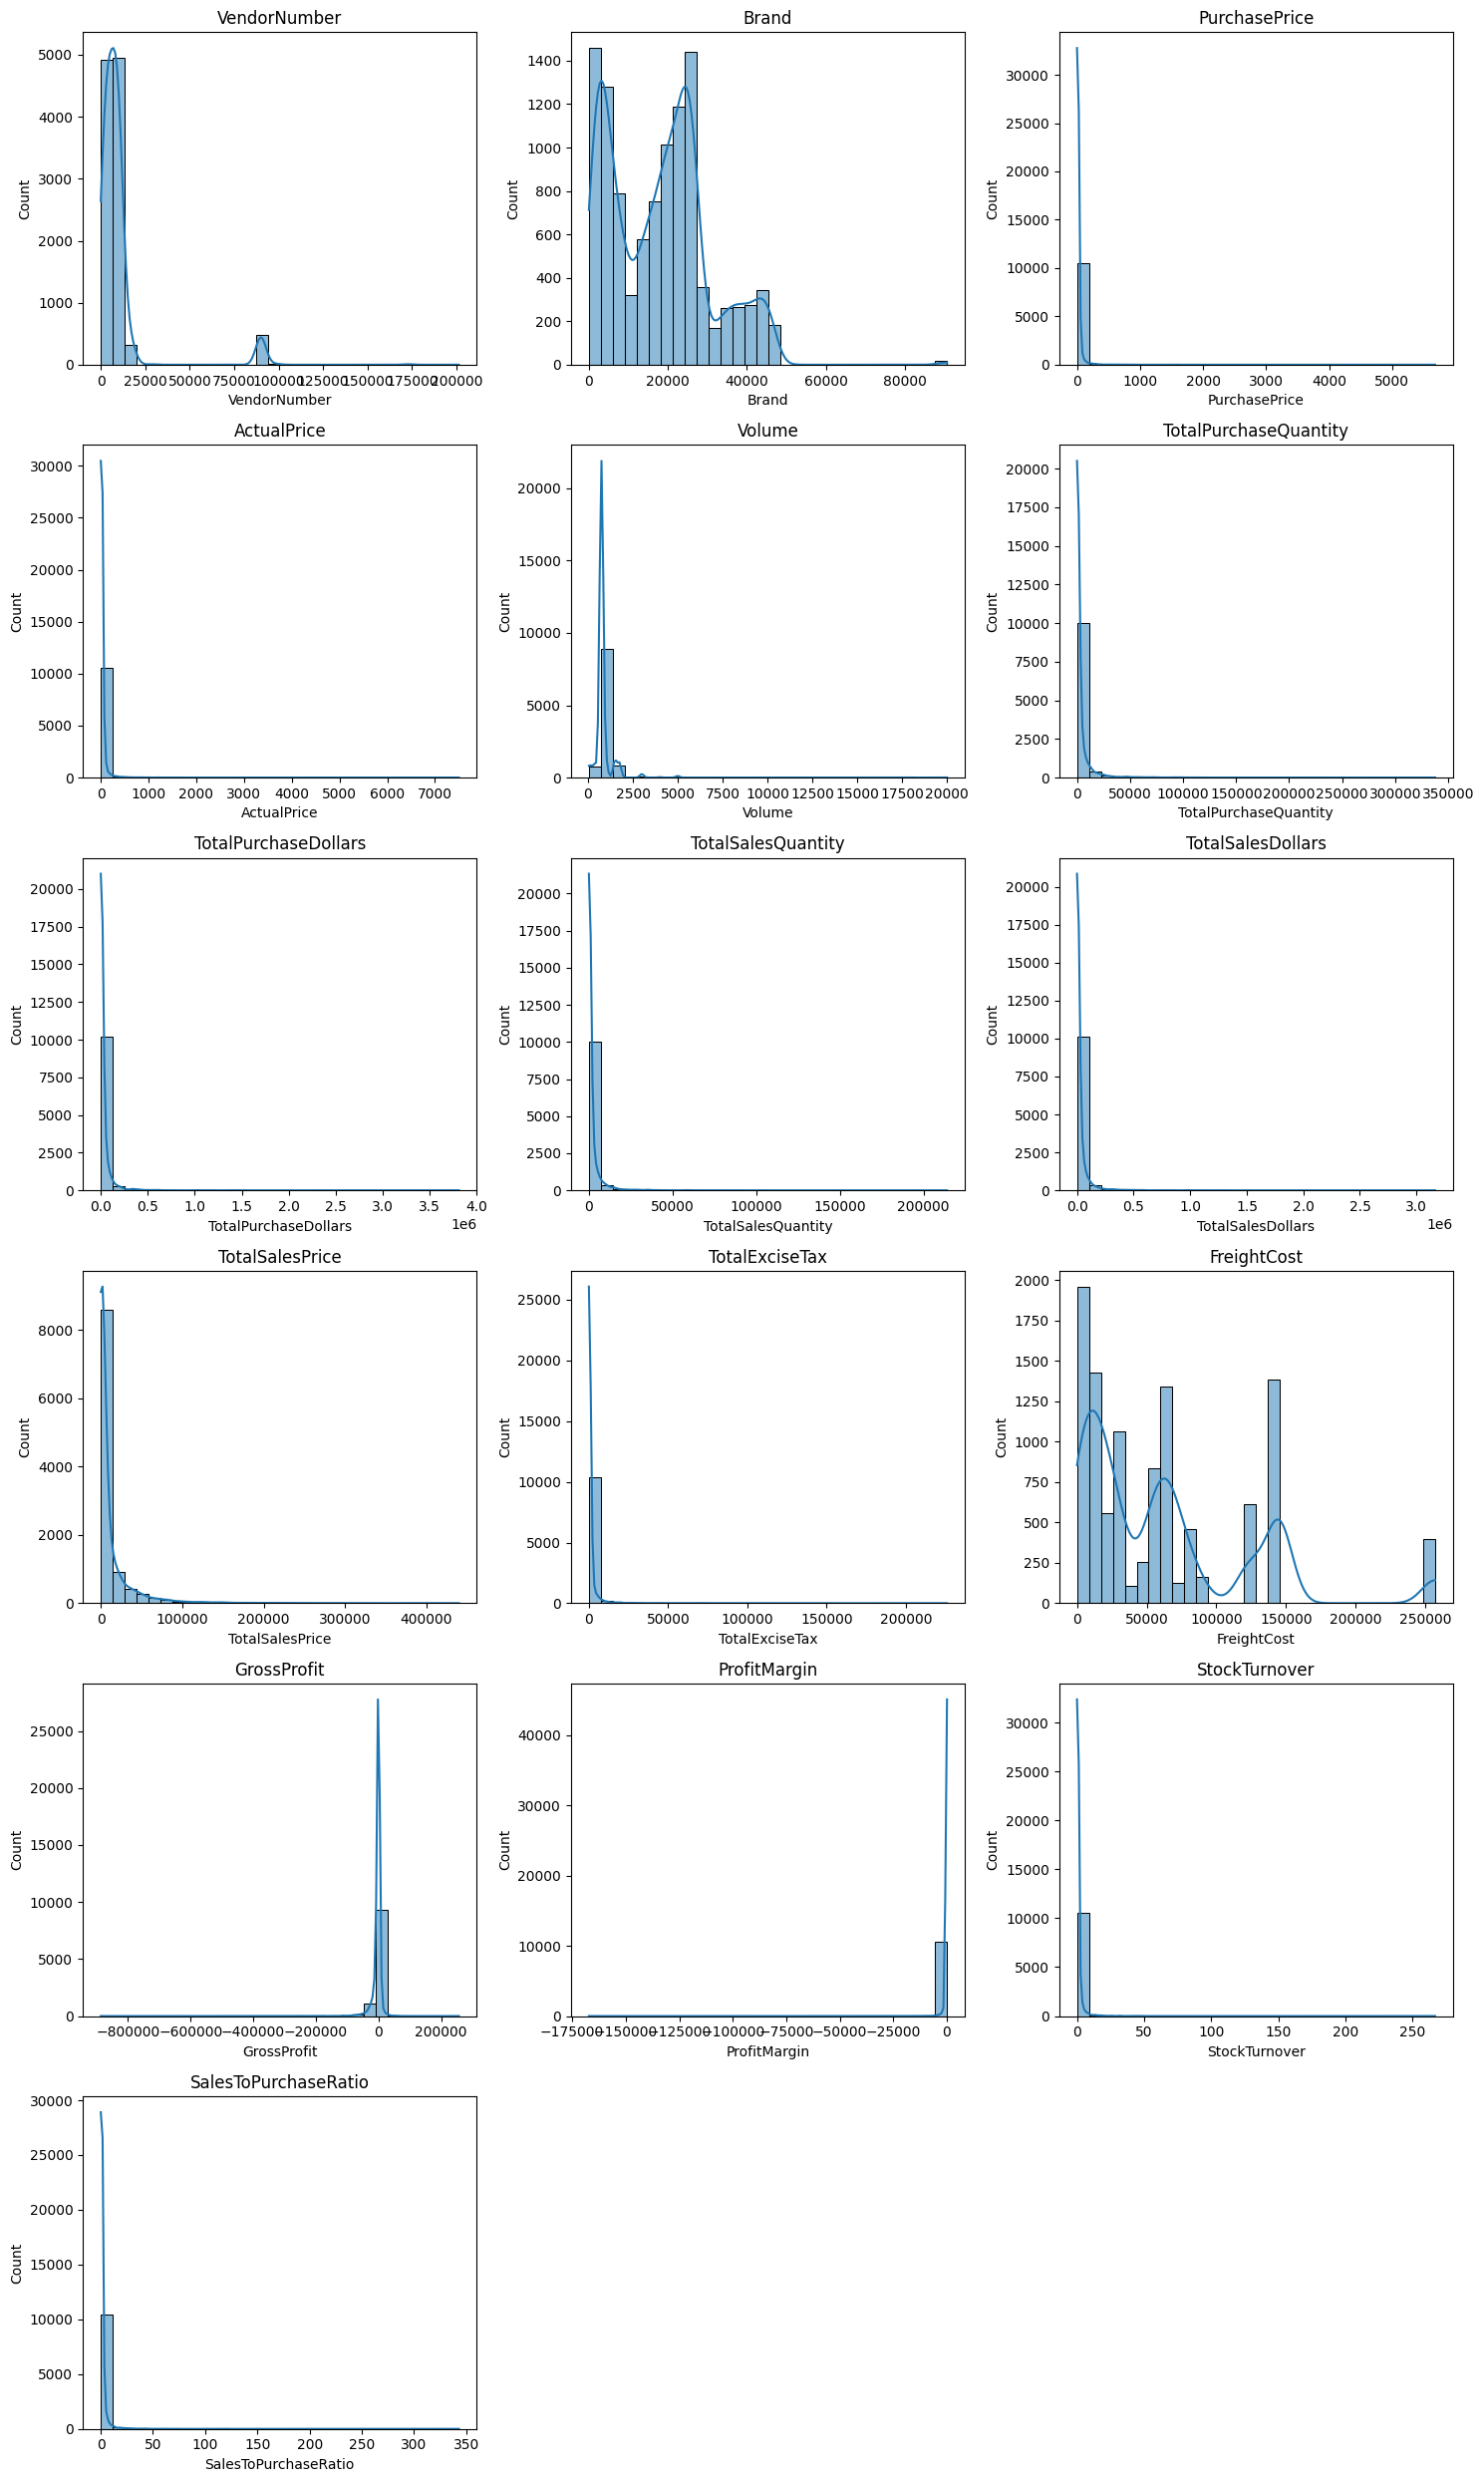

In [186]:
# Distribution Plots for Numerical Columns

numerical_cols = vendor_sales_summary.select_dtypes(include=np.number).columns

print(f"Numerical columns: {list(numerical_cols)}")
print(f"Number of numerical columns: {len(numerical_cols)}")

plt.figure(figsize=(15,25)) # Adjusted figure size for 6 rows
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 3, i+1) # Adjusted grid layout to 6 rows and 3 columns
    sns.histplot(vendor_sales_summary[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

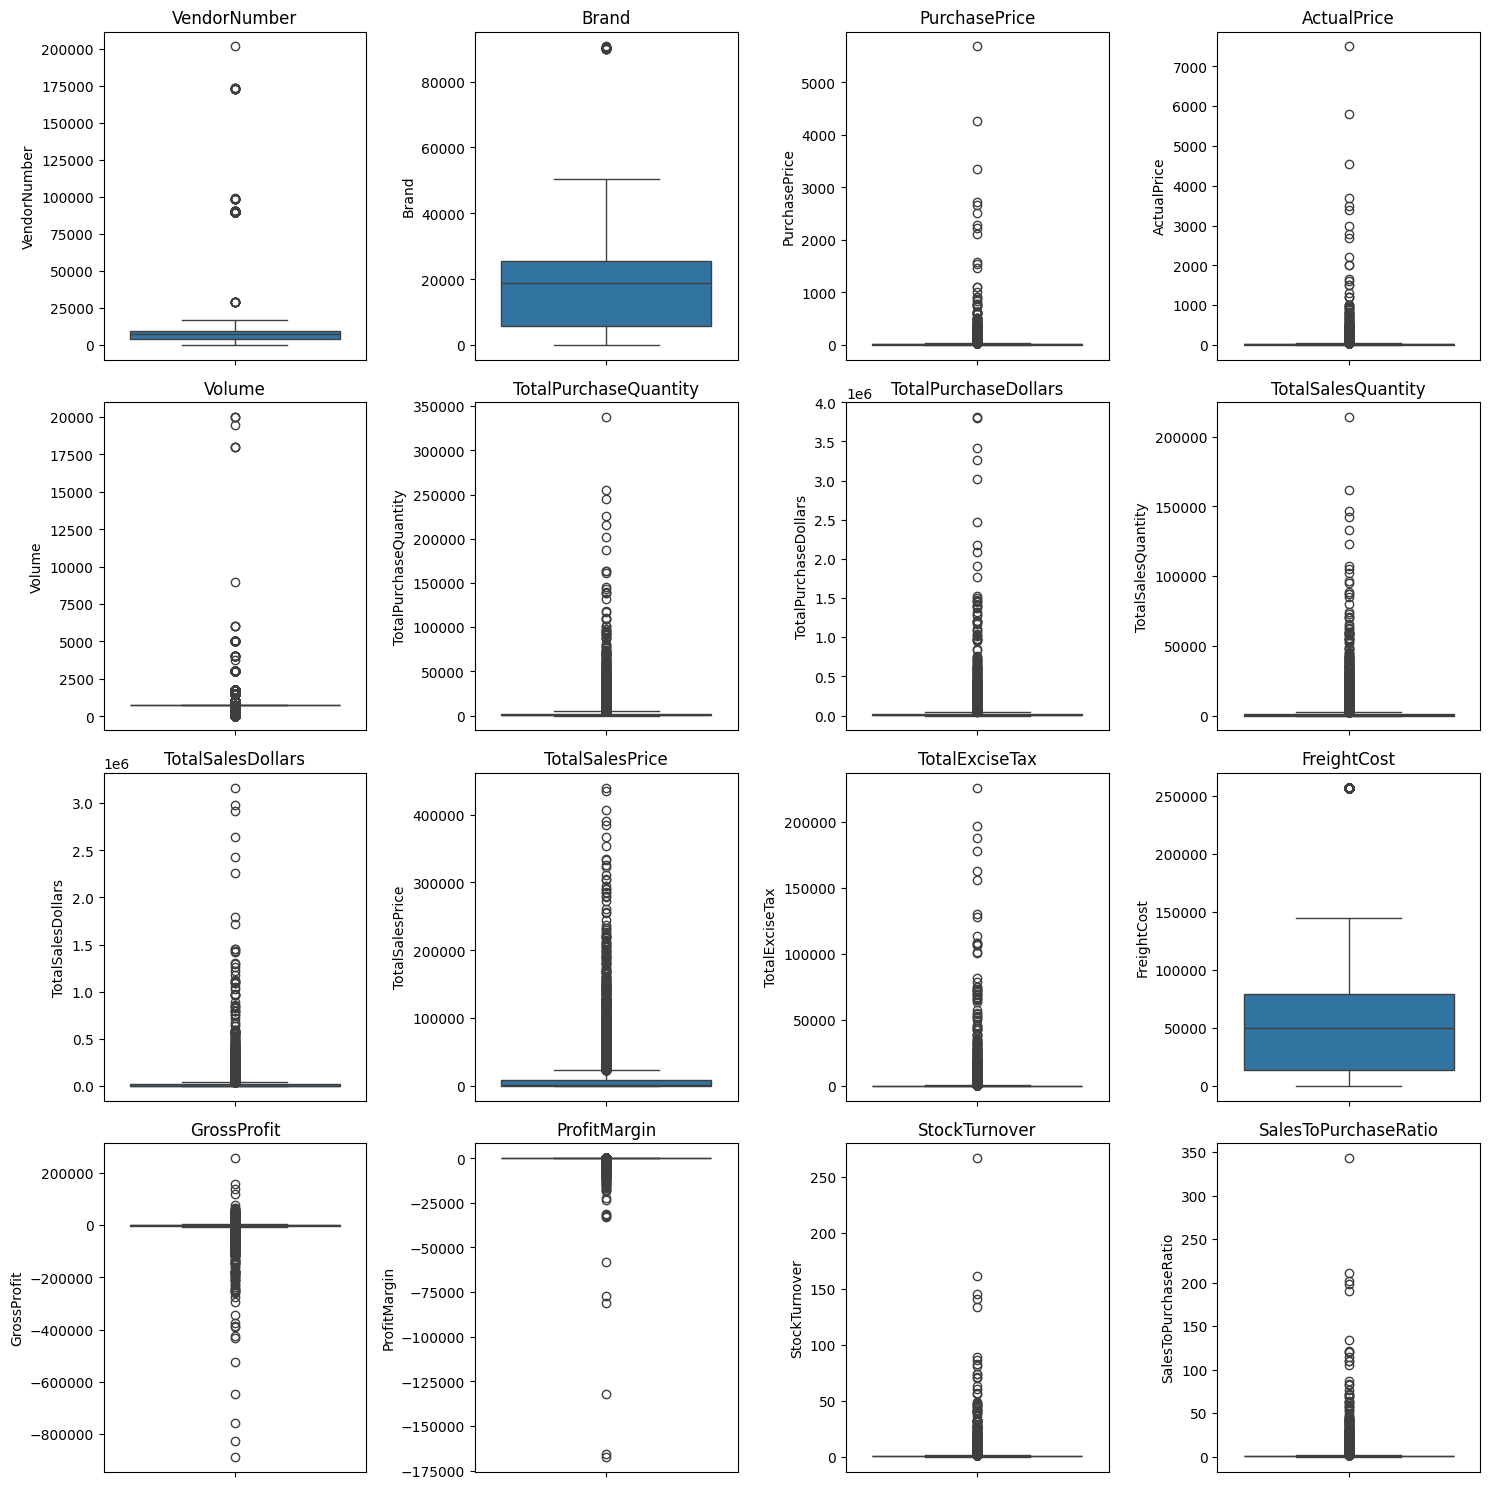

In [187]:
# Outlier Detection with Boxplots
numerical_cols = vendor_sales_summary.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,15)) # Adjusted figure size for 4 rows
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) # Adjusted grid layout to 4 rows and 4 columns for 16 plots
    sns.boxplot(y=vendor_sales_summary[col])
    plt.title(col)
plt.tight_layout()
plt.show()

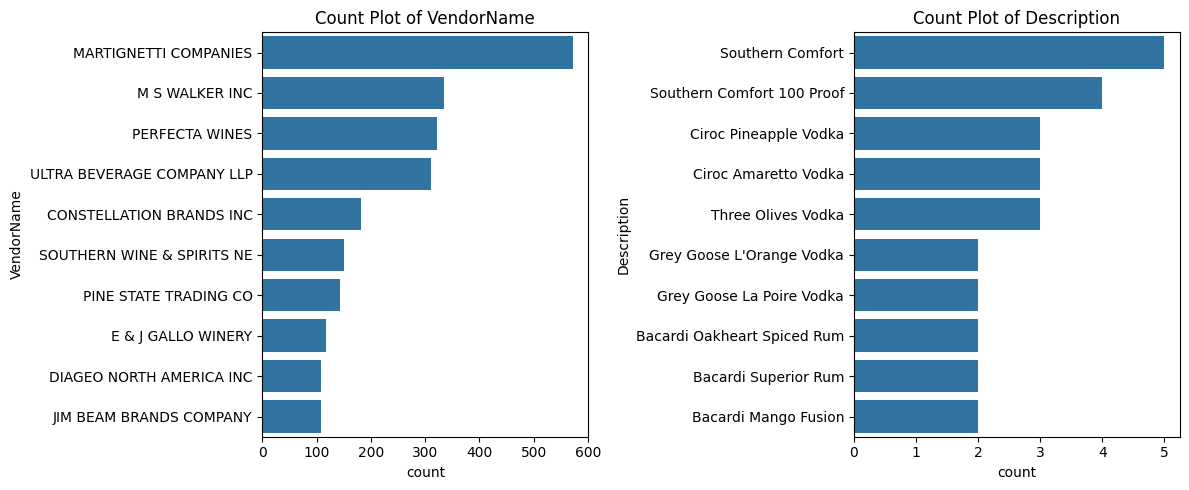

In [188]:
# count plots for categorical columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,5))
for i, col, in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

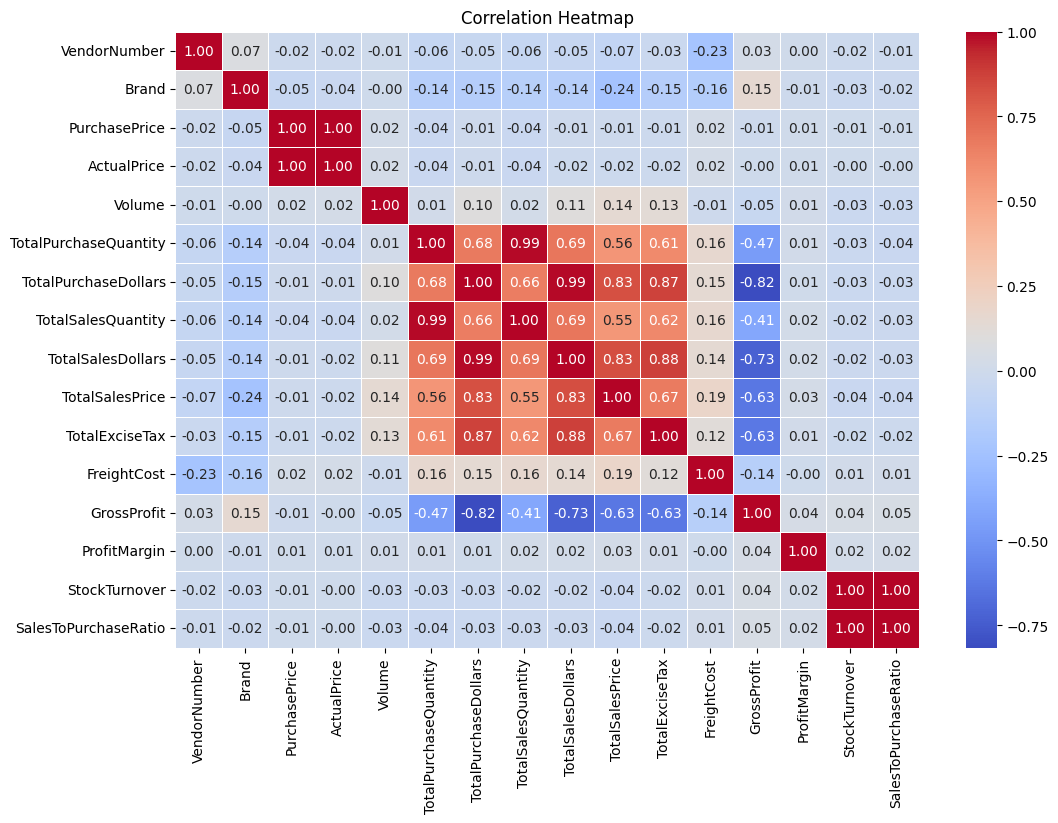

In [191]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
numerical_cols = vendor_sales_summary.select_dtypes(include=np.number).columns
correlation_matrix = vendor_sales_summary[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit(-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
* A weak positive correlation between Profit Margin & Total Sales Price (0.03) suggests that as sales price increases, profit margin increases slightly, but the relationship is negligible and not practically significant.
* StockTurnover has very weak positive correlations with both GrossProfit (0.04) and ProfitMargin (0.02), indicating that faster inventory turnover does not meaningfully improve profitability.

# Data Analysis

#### Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins. --> To increase/maximize sales revenue

In [192]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

display(brand_performance)
    

,Description,TotalSalesDollars,ProfitMargin
0,10 Span Pnt Gris Monterey Cy,1438.08,1.87
1,12 Days of Pearls Gift Set,309.69,97.68
2,13 Celsius Svgn Bl,20126.00,28.40
3,14 Hands Chard Wash,36153.59,0.83
4,14 Hands Hot to Trot White,10589.87,8.26
...,...,...,...
3682,Zinsane Znfdl Lodi,14733.56,98.38
3683,Zion Dolev Muscato,1208.90,69.50
3684,Zonin Moscato,239.76,18.32
3685,Zorah Red,417.81,67.56


In [193]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)


In [194]:
print(low_sales_threshold)

382.849


In [195]:
print(high_margin_threshold)

79.916


In [196]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with low sales but high profit margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
1127,Concannon Glen Ellen Wh Zin,15.95,83.45
1187,Crown Royal Apple,23.88,88.11
3005,Sauza Sprklg Wild Berry Marg,27.96,82.15
3449,Tracia Syrah,44.94,88.50
300,Basilica Amaretto,47.45,85.08
...,...,...,...
3195,St Elder Elderflower Liqueur,359.37,98.42
198,Auchentoshan Classic Scotch,359.88,94.40
3200,St Germain Liqueur,374.75,97.04
988,Chanrion Cote de Brouilly,379.80,93.33


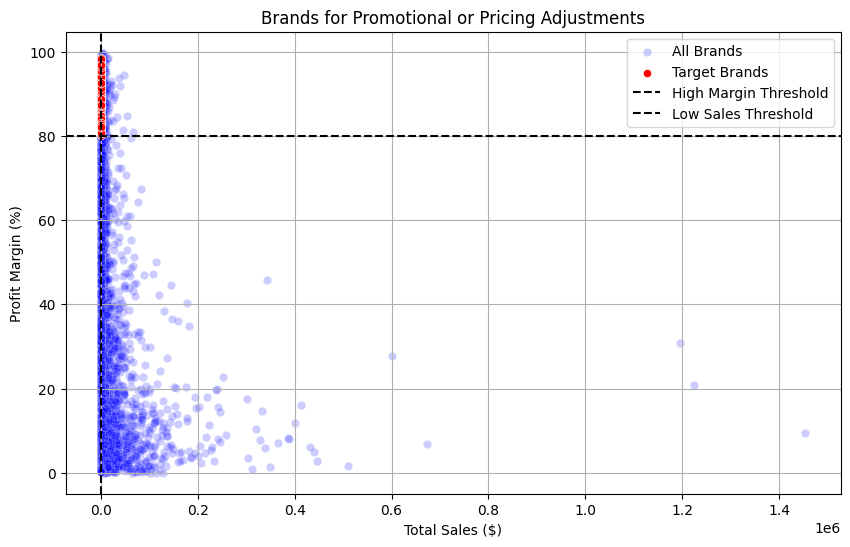

In [197]:
# plot scatter plot for the brand above threshold and below.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(y=high_margin_threshold, color='black', linestyle='--', label="High Margin Threshold")
plt.axvline(x=low_sales_threshold, color='black', linestyle='--', label="Low Sales Threshold")

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional or Pricing Adjustments')
plt.legend()
plt.grid(True)
plt.show()

In [198]:
# Filtering out For Better Visualization
brand_performance= brand_performance[brand_performance['TotalSalesDollars'] <1000]

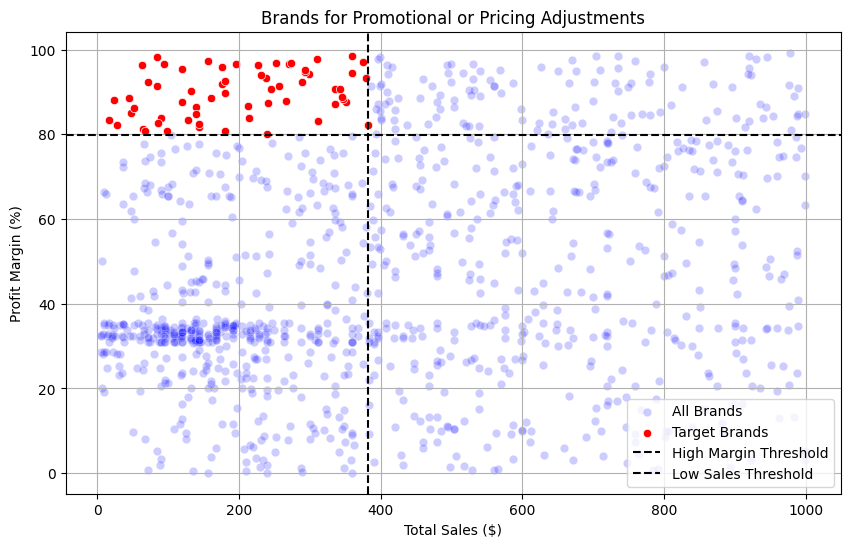

In [199]:
# plot scatter plot for the brand above threshold and below.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(y=high_margin_threshold, color='black', linestyle='--', label="High Margin Threshold")
plt.axvline(x=low_sales_threshold, color='black', linestyle='--', label="Low Sales Threshold")

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional or Pricing Adjustments')
plt.legend()
plt.grid(True)
plt.show()

#### Which vendors and brands demonstrate the highest sales performance?




In [206]:
# Top Vendors & brands by sales performance
top_vendors = vendor_sales_summary.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = vendor_sales_summary.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

print("Top 10 Vendors by Total Sales Dollars:")
display(top_vendors)

print("\nTop 10 Brands by Total Sales Dollars:")
display(top_brands)

Top 10 Vendors by Total Sales Dollars:


VendorName
DIAGEO NORTH AMERICA INC      41184766.00
MARTIGNETTI COMPANIES         24722486.15
JIM BEAM BRANDS COMPANY       19788465.33
PERNOD RICARD USA             19440345.35
BACARDI USA INC               15967237.22
CONSTELLATION BRANDS INC      15033282.86
BROWN-FORMAN CORP             11329447.54
E & J GALLO WINERY            11205701.28
ULTRA BEVERAGE COMPANY LLP    10889014.26
M S WALKER INC                 9274264.17
Name: TotalSalesDollars, dtype: float64


Top 10 Brands by Total Sales Dollars:


Description
Jack Daniels No 7 Black    4865104.11
Grey Goose Vodka           4637792.69
Tito's Handmade Vodka      4418601.09
Absolut 80 Proof           4036120.09
Capt Morgan Spiced Rum     3547881.99
Ketel One Vodka            3156560.76
Jameson Irish Whiskey      3085323.29
Tanqueray                  2240799.22
Baileys Irish Cream        2132095.48
Kahlua                     2131606.35
Name: TotalSalesDollars, dtype: float64

In [218]:
# To convert into Millions and Thousands to read easy

import pandas as pd

def format_dollars(x):
    x = float(x)
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:,.2f}M"
    elif abs(x) >= 1_000:
        return f"${x/1_000:,.2f}K"
    else:
        return f"${x:,.2f}"

print("Top 10 Vendors by Total Sales Dollars:")
print(top_vendors.map(format_dollars))

print("\nTop 10 Brands by Total Sales Dollars:")
print(top_brands.map(format_dollars))


Top 10 Vendors by Total Sales Dollars:
VendorName
CONSTELLATION BRANDS INC      $8.71M
MARTIGNETTI COMPANIES         $8.56M
ULTRA BEVERAGE COMPANY LLP    $3.68M
E & J GALLO WINERY            $3.50M
WINE GROUP INC                $3.31M
DIAGEO NORTH AMERICA INC      $3.17M
PROXIMO SPIRITS INC.          $3.16M
BACARDI USA INC               $2.95M
M S WALKER INC                $2.75M
TREASURY WINE ESTATES         $2.35M
Name: TotalSalesDollars, dtype: str

Top 10 Brands by Total Sales Dollars:
Description
Capt Morgan Original Barrel      $1.45M
Bacardi Superior Rum Trav        $1.22M
Three Olives Vodka               $1.19M
R M Woodbridge Chard Cal       $673.97K
Southern Comfort               $600.06K
MezzaCorona Pnt Grigio         $509.17K
Clos du Bois Chard             $446.70K
1800 Silver Tequila            $440.87K
R M Woodbridge Cab Svgn Cal    $430.88K
Bogle Chard                    $412.37K
Name: TotalSalesDollars, dtype: str


C:\Users\Hii\AppData\Local\Temp\ipykernel_28996\2671838923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=top_vendors.index, y=top_vendors.values, palette='viridis')


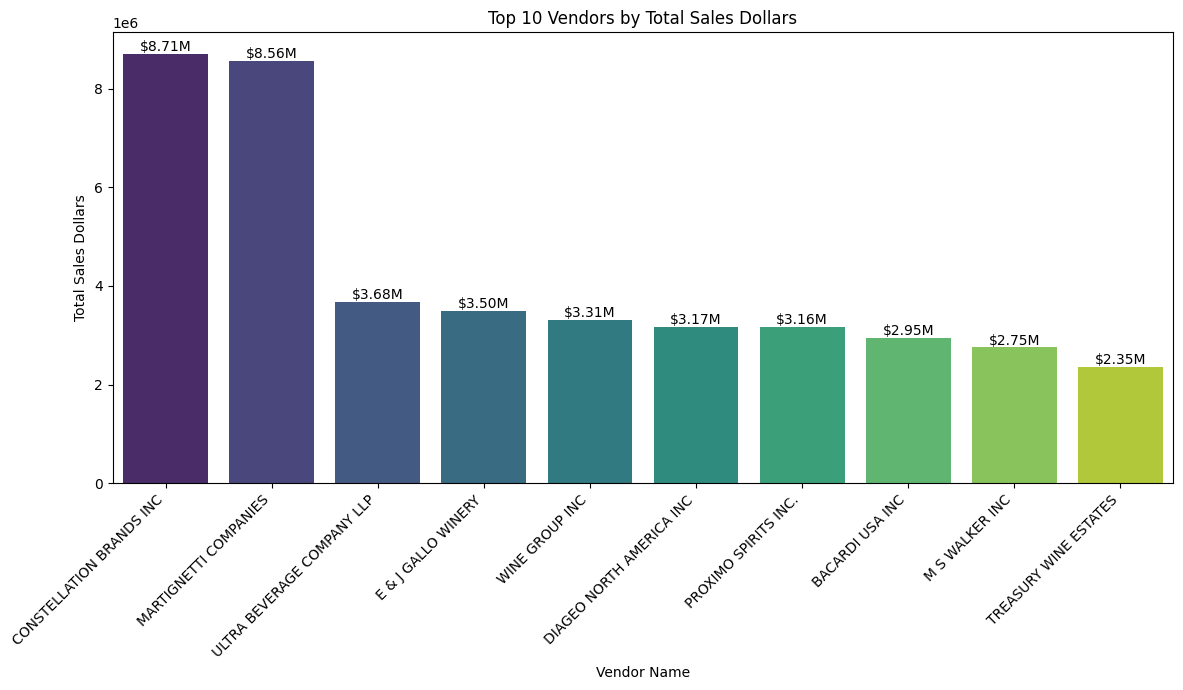

C:\Users\Hii\AppData\Local\Temp\ipykernel_28996\2671838923.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')


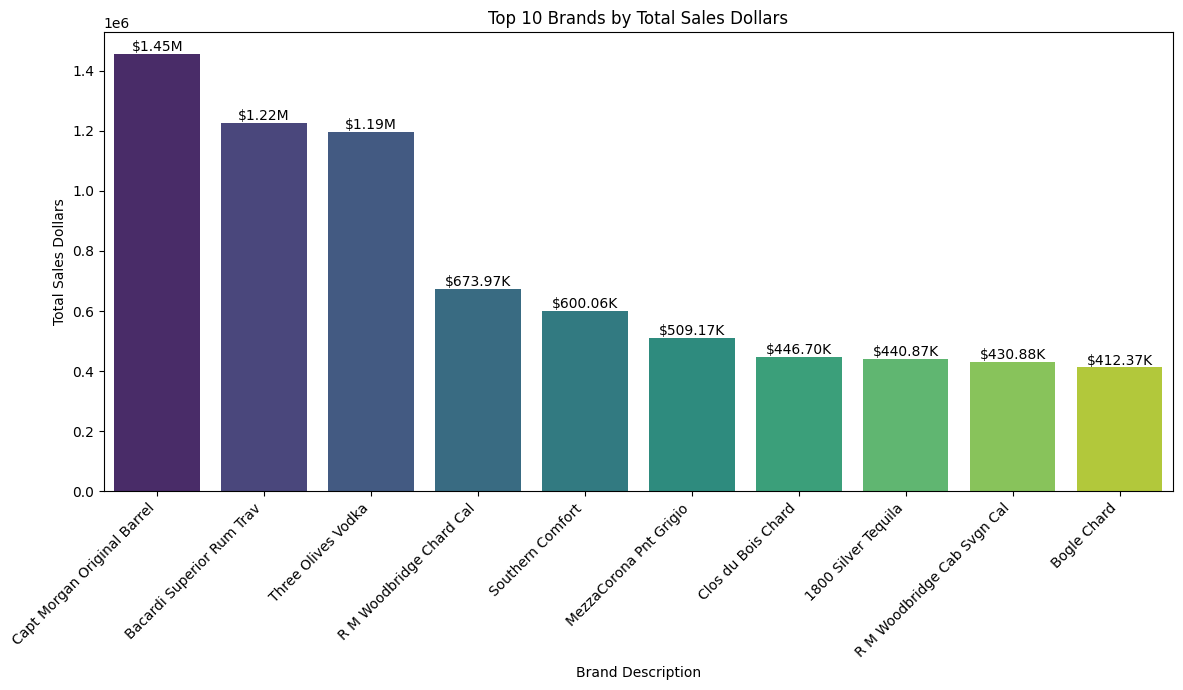

In [219]:
# Plotting Top 10 Vendors by Total Sales Dollars
plt.figure(figsize=(12, 7))
ax1 = sns.barplot(x=top_vendors.index, y=top_vendors.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Vendor Name')
plt.ylabel('Total Sales Dollars')
plt.title('Top 10 Vendors by Total Sales Dollars')
plt.tight_layout()

# Add text labels on top of bars
for p in ax1.patches:
    ax1.annotate(format_dollars(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()


# Plotting Top 10 Brands by Total Sales Dollars
plt.figure(figsize=(12, 7))
ax2 = sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Brand Description')
plt.ylabel('Total Sales Dollars')
plt.title('Top 10 Brands by Total Sales Dollars')
plt.tight_layout()

# Add text labels on top of bars
for p in ax2.patches:
    ax2.annotate(format_dollars(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

#### Which Vendor contribute the most to total purchase dollars?

In [220]:
vendor_performance = vendor_sales_summary.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
display(vendor_performance)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00
1,ADAMBA IMPORTS INTL INC,76770.25,-51454.06,25316.19
2,ALISA CARR BEVERAGES,34951.68,45264.64,80216.32
3,ALTAMAR BRANDS LLC,11706.20,-2428.08,9278.12
4,AMERICAN SPIRITS EXCHANGE,1205.16,-762.41,442.75
...,...,...,...,...
123,WEIN BAUER INC,43517.00,-13681.95,29835.05
124,WESTERN SPIRITS BEVERAGE CO,361249.21,-89684.06,271565.15
125,WILLIAM GRANT & SONS INC,5960744.35,-1492719.49,4468024.86
126,WINE GROUP INC,5258636.79,40804.84,5299441.63


In [230]:
vendor_performance = vendor_sales_summary.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance.shape

(128, 4)

In [227]:
vendor_performance['PurchaseContribution%'] = (vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum())*100
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,50959796.85,-9775030.85,41184766.00,15.830903
63,MARTIGNETTI COMPANIES,27861690.02,-3139203.87,24722486.15,8.655366
50,JIM BEAM BRANDS COMPANY,24203151.05,-4414685.72,19788465.33,7.518824
74,PERNOD RICARD USA,24124091.56,-4683746.21,19440345.35,7.494263
8,BACARDI USA INC,17624378.72,-1657141.50,15967237.22,5.475097
...,...,...,...,...,...
36,FANTASY FINE WINES CORP,128.64,95.08,223.72,0.000040
0,AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00,0.000033
91,SILVER MOUNTAIN CIDERS,77.18,251.35,328.53,0.000024
19,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.000017


In [228]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,50959796.85,-9775030.85,41184766.00,15.83
63,MARTIGNETTI COMPANIES,27861690.02,-3139203.87,24722486.15,8.66
50,JIM BEAM BRANDS COMPANY,24203151.05,-4414685.72,19788465.33,7.52
74,PERNOD RICARD USA,24124091.56,-4683746.21,19440345.35,7.49
8,BACARDI USA INC,17624378.72,-1657141.50,15967237.22,5.48
...,...,...,...,...,...
36,FANTASY FINE WINES CORP,128.64,95.08,223.72,0.00
0,AAPER ALCOHOL & CHEMICAL CO,105.07,-105.07,0.00,0.00
91,SILVER MOUNTAIN CIDERS,77.18,251.35,328.53,0.00
19,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [229]:
# Display Top 10 Vendors

top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
28,DIAGEO NORTH AMERICA INC,$50.96M,$-9.78M,$41.18M,15.83
63,MARTIGNETTI COMPANIES,$27.86M,$-3.14M,$24.72M,8.66
50,JIM BEAM BRANDS COMPANY,$24.20M,$-4.41M,$19.79M,7.52
74,PERNOD RICARD USA,$24.12M,$-4.68M,$19.44M,7.49
8,BACARDI USA INC,$17.62M,$-1.66M,$15.97M,5.48
23,CONSTELLATION BRANDS INC,$15.57M,$-540.64K,$15.03M,4.84
14,BROWN-FORMAN CORP,$13.53M,$-2.20M,$11.33M,4.20
114,ULTRA BEVERAGE COMPANY LLP,$13.21M,$-2.32M,$10.89M,4.10
33,E & J GALLO WINERY,$12.29M,$-1.08M,$11.21M,3.82
59,M S WALKER INC,$10.94M,$-1.66M,$9.27M,3.40


In [235]:
print(top_vendors['PurchaseContribution%'].sum(),"%")

65.34 %


 Top 10 Vendor Contribution 65% to Total Purchase

In [249]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cummulative_Contribution%,Cumulative_Contribution%
28,DIAGEO NORTH AMERICA INC,$50.96M,$-9.78M,$41.18M,15.83,15.83,15.83
63,MARTIGNETTI COMPANIES,$27.86M,$-3.14M,$24.72M,8.66,24.49,24.49
50,JIM BEAM BRANDS COMPANY,$24.20M,$-4.41M,$19.79M,7.52,32.01,32.01
74,PERNOD RICARD USA,$24.12M,$-4.68M,$19.44M,7.49,39.50,39.50
8,BACARDI USA INC,$17.62M,$-1.66M,$15.97M,5.48,44.98,44.98
23,CONSTELLATION BRANDS INC,$15.57M,$-540.64K,$15.03M,4.84,49.82,49.82
14,BROWN-FORMAN CORP,$13.53M,$-2.20M,$11.33M,4.20,54.02,54.02
114,ULTRA BEVERAGE COMPANY LLP,$13.21M,$-2.32M,$10.89M,4.10,58.12,58.12
33,E & J GALLO WINERY,$12.29M,$-1.08M,$11.21M,3.82,61.94,61.94
59,M S WALKER INC,$10.94M,$-1.66M,$9.27M,3.40,65.34,65.34


C:\Users\Hii\AppData\Local\Temp\ipykernel_28996\4102365651.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)
C:\Users\Hii\AppData\Local\Temp\ipykernel_28996\4102365651.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)


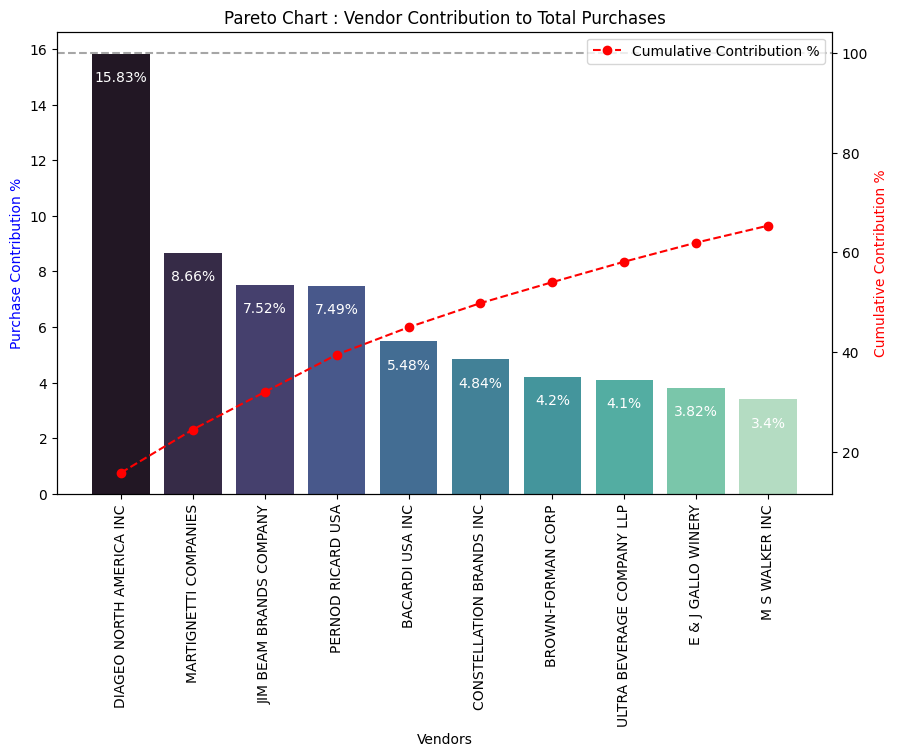

In [250]:
# Pareto Chart

top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar Plot for Purchase Contribution%

sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')


# Line Plot for Cumulative Contribution %
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution %')


ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart : Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')


plt.show()

#### How much of total procurement is dependent on the top vendors?

In [251]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")


Total Purchase Contribution of top 10 vendors is 65.34%


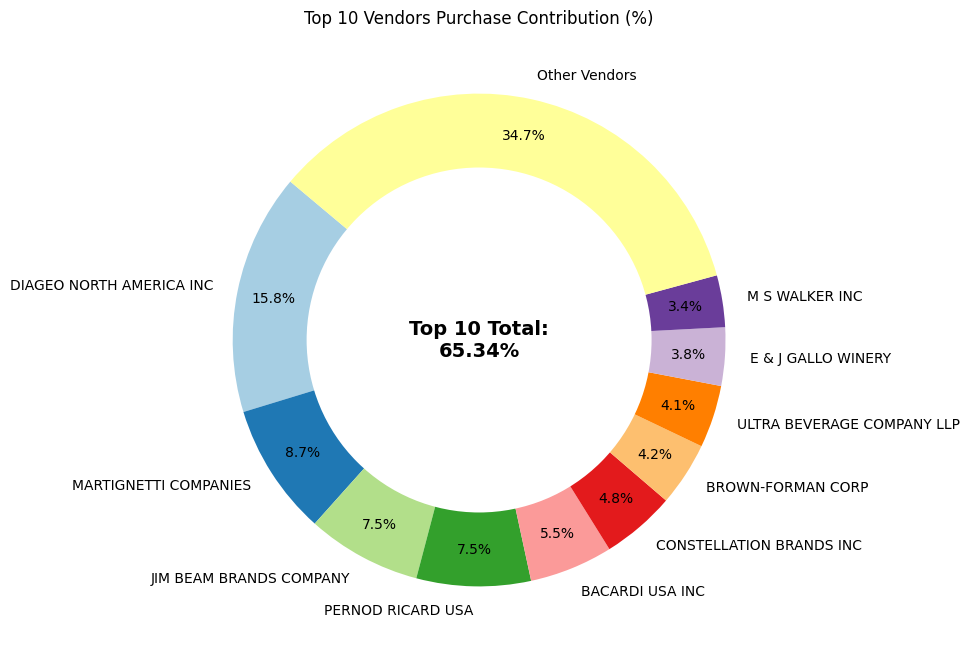

In [253]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "other vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%', startangle=140, pctdistance = 0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
center_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

# Add Total Contribution annotation in the center
plt.text(0,0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendors Purchase Contribution (%)")
plt.show()

vendor_sales_summary ---> df

#### Does Purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings ?


In [255]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,8,190.88,16,591.84,258.93,1.78,27.08,400.96,67.75,2.00,3.10,23.86
1,388,ATLANTIC IMPORTING COMPANY,2119,Glendalough 13 Yr Sngle Malt,66.40,89.99,750,39,2589.60,87,7459.13,4799.44,68.61,211.74,4869.53,65.28,2.23,2.88,66.40
2,388,ATLANTIC IMPORTING COMPANY,7241,Glendalough Poitin Shry Cask,20.68,34.99,750,31,641.08,98,3039.02,2449.19,10.82,211.74,2397.94,78.91,3.16,4.74,20.68
3,480,BACARDI USA INC,129,Grey Goose L'Orange Vodka,24.99,31.99,1000,4,99.96,7,221.93,189.94,7.35,89286.27,121.97,54.96,1.75,2.22,24.99
4,480,BACARDI USA INC,540,Bacardi Pineapple Fusion,0.72,0.99,50,352,253.44,4452,4407.48,1898.82,229.43,89286.27,4154.04,94.25,12.65,17.39,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3805,98450,Serralles Usa LLC,5953,Barrow's Intense Ginger,15.87,19.99,375,209,3316.83,205,4097.95,2718.64,80.36,856.02,781.12,19.06,0.98,1.24,15.87
3806,98450,Serralles Usa LLC,6877,Original Wondermint Schnapps,13.56,18.99,750,11,149.16,39,740.61,683.64,30.79,856.02,591.45,79.86,3.55,4.97,13.56
3807,98450,Serralles Usa LLC,7890,Barrow's Intense Ginger,22.21,29.99,750,87,1932.27,83,2489.17,1169.61,65.38,856.02,556.90,22.37,0.95,1.29,22.21
3808,98450,Serralles Usa LLC,8543,Kringle Cream,14.81,19.99,750,172,2547.32,322,5492.78,3597.90,253.82,856.02,2945.46,53.62,1.87,2.16,14.81


In [256]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [257]:
df[['OrderSize', 'TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Small,8
1,Medium,39
2,Medium,31
3,Small,4
4,Medium,352
...,...,...
3805,Medium,209
3806,Small,11
3807,Medium,87
3808,Medium,172


In [258]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,49.438472
Medium,18.802114
Large,8.582474


C:\Users\Hii\AppData\Local\Temp\ipykernel_28996\3891548300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x='OrderSize', y='UnitPurchasePrice', palette="Set2")


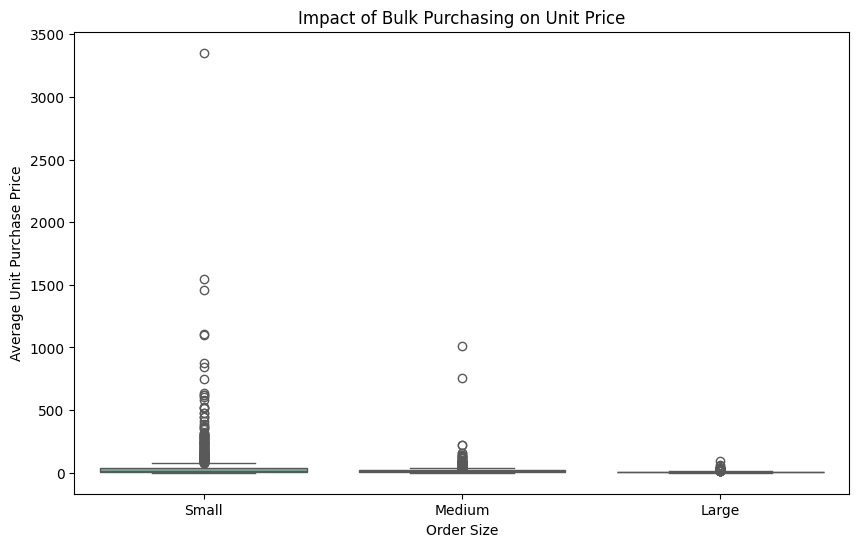

In [261]:
plt.figure(figsize=(10, 6))
sns.boxplot(data = df, x='OrderSize', y='UnitPurchasePrice', palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendor buying in bulk (large order size) get the lowest unit price($8.58 per unit), meaning higher margins if they can manage inventory efficiency.
* The price difference between small and large orders is substantial (~ 82.65% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourages vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

#### Which vendors have low inventory turnover, indicating excess stock and slow moving products ?

In [262]:
df[df['StockTurnover']<1].groupby('VendorName')[["StockTurnover"]].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
THE IMPORTED GRAPE LLC,0.600000
JEWELL TOWNE VINEYARDS,0.620000
DISARONNO INTERNATIONAL LLC,0.630000
LATITUDE BEVERAGE COMPANY,0.650000
ALISA CARR BEVERAGES,0.650000
WINE GROUP INC,0.655636
PARK STREET IMPORTS LLC,0.670000
Dunn Wine Brokers,0.670000
TAKARA SAKE USA INC,0.670000


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [263]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"])*df["PurchasePrice"]
print('Total Unsold Capital :', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital : $11.23M


In [266]:
# Aggregate Capital Locked  per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor = inventory_value_per_vendor.sort_values("UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
38,KOBRAND CORPORATION,$93.78K
77,STELLAR IMPORTING CO LLC,$927.96
48,MHW LTD,$91.63K
23,E & J GALLO WINERY,$907.38K
66,SAZERAC CO INC,$89.82K
79,SURVILLE ENTERPRISES CORP,$771.20
53,OLE SMOKY DISTILLERY LLC,$73.23
6,BRONCO WINE COMPANY,$71.40
61,PROXIMO SPIRITS INC.,$704.97K
41,LATITUDE BEVERAGE COMPANY,$66.79K


# Statistics

#### What is the 95% confidense intervals for profit margins of top-performing and low-performing vendors.

In [267]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [269]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()


In [270]:
top_vendors

6       54.68
12      28.51
16      91.71
19      45.90
20      13.19
        ...  
3726    13.07
3736     1.63
3741     5.94
3742    11.57
3796    79.20
Name: ProfitMargin, Length: 953, dtype: float64

In [271]:
low_vendors

0       67.75
3       54.96
5       33.34
9       23.07
24      59.82
        ...  
3801    31.02
3802    41.39
3803    60.01
3804    40.47
3809    96.60
Name: ProfitMargin, Length: 953, dtype: float64

In [274]:
!pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.3 MB 8.8 MB/s eta 0:00:05
   --- ------------------------------------ 2.9/37.3 MB 7.5 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/37.3 MB 7.2 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/37.3 MB 7.6 MB/s eta 0:00:05
   -------- ------------------------------- 8.1/37.3 MB 8.0 MB/s eta 0:00:04
   ---------- ----------------------------- 9.7/37.3 MB 8.2 MB/s eta 0:00:04
   ------------ --------------------------- 11.8/37.3 MB 8.3 MB/s eta 0:00:04
   -------------- ------------------------- 13.6/37.3 MB 8.4 MB/s eta 0:00:03
   ---------------- ----------------------- 15.5/37.3 MB 8.5 MB/s eta 0:00:03
   ------------------ --------------------- 17.3/37.3 MB 8.6 MB/s eta 0:00:03
   -------------------- ------------------- 19.4/37.3 MB 8.7 MB/s eta 0:00:03
   ---------------------- ----------------- 21.2/37.3 MB 8.7 MB/s eta 0:00:02



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [275]:
import scipy
print(scipy.__version__)

1.17.1


In [276]:
from scipy.stats import ttest_ind
import scipy.stats as stats

In [277]:
# confidence interval
def confidence_interval(data, confidence=0.95):
  mean_val = np.mean(data)
  std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
  t_critical = stats.t.ppf((1+confidence)/2, df=len(data)-1)
  margin_of_error = t_critical * std_err
  return mean_val, mean_val - margin_of_error, mean_val + margin_of_error # deviation from mean

Top Vendors 95% CI :  (18.29, 20.93), Mean: 19.61
Low Vendors 95% CI :  (44.83, 48.19), Mean: 46.51


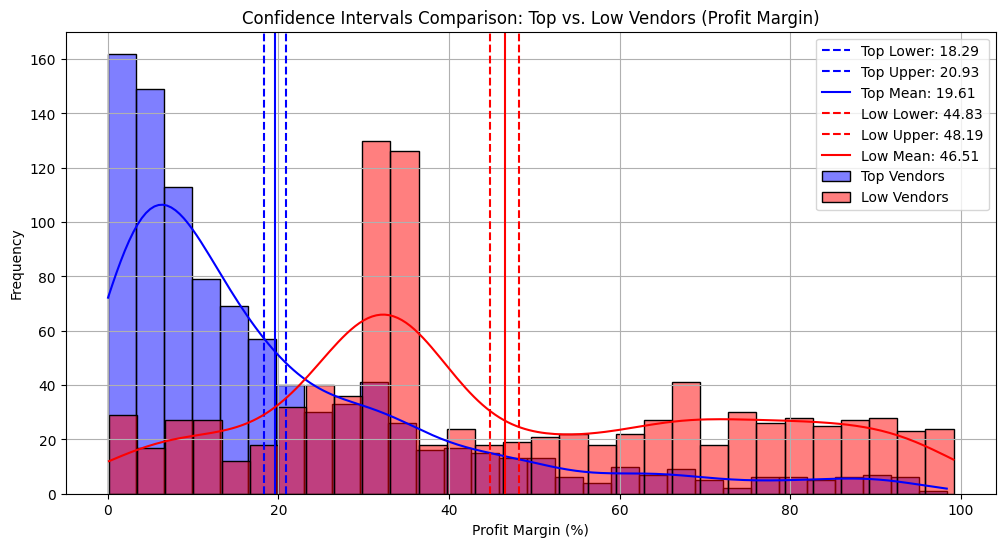

In [278]:

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI :  ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI :  ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, bins=30, color='blue', alpha=0.5, label='Top Vendors')
plt.axvline(top_lower, color='blue', linestyle='--', label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color='blue', linestyle='--', label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color='blue', linestyle='-', label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, bins=30, color='red', alpha=0.5, label='Low Vendors')
plt.axvline(low_lower, color='red', linestyle='--', label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color='red', linestyle='--', label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color='red', linestyle='-', label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Intervals Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


* profit margin of top performing vendor is low
* profit margin of low performing vendor is high

* The confidence interval for low-performing vendors (44.83, 48.19) is significantly higher than that of top performing vendors (18.29, 20.93).
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors : If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors : Despite higher margins, their low sales volumne might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors?
Hypothesis Testing:

Hypothesis:
* H0 (Null Hypothesis) : There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
* H1 (Alternative Hypothesis) : The mean profit margins of top-performing and low-performing vendors are significantly different.

In [280]:

top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print Results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
  print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")
else:
  print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -24.6988, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.


# Download .ipynb file into .csv file

In [282]:
vendor_sales_summary.head(3).T

,0,1,2
VendorNumber,1128,4425,17035
VendorName,BROWN-FORMAN CORP,MARTIGNETTI COMPANIES,PERNOD RICARD USA
Brand,1233,3405,8068
Description,Jack Daniels No 7 Black,Tito's Handmade Vodka,Absolut 80 Proof
PurchasePrice,26.27,23.19,18.24
ActualPrice,36.99,28.99,24.99
Volume,1750,1750,1750
TotalPurchaseQuantity,145080,164038,187407
TotalPurchaseDollars,3811251.6,3804041.22,3418303.68
TotalSalesQuantity,88517,96698,122981


In [283]:
df.to_csv('Vendor&Inventory.csv')

In [284]:
import os
print(os.getcwd())

C:\Users\Hii\Desktop\Jupyter Notebook


In [286]:
df.shape

(3810, 21)

In [287]:
df.columns.tolist()

['VendorNumber',
 'VendorName',
 'Brand',
 'Description',
 'PurchasePrice',
 'ActualPrice',
 'Volume',
 'TotalPurchaseQuantity',
 'TotalPurchaseDollars',
 'TotalSalesQuantity',
 'TotalSalesDollars',
 'TotalSalesPrice',
 'TotalExciseTax',
 'FreightCost',
 'GrossProfit',
 'ProfitMargin',
 'StockTurnover',
 'SalesToPurchaseRatio',
 'UnitPurchasePrice',
 'OrderSize',
 'UnsoldInventoryValue']